## Project Aim

The capstone question is:

> Can machine learning models predict whether a patient with diabetes will be readmitted to the hospital within 30 days, and does HbA1c measurement or other discharge time information improve that prediction?

This is a predictive modeling question, not a causal claim. If a model predicts better, that does not prove that HbA1c testing causes lower readmission.


## 1. Data Source

The dataset is the UCI **Diabetes 130-US Hospitals for Years 1999-2008** dataset, associated with:

Strack, Beata, DeShazo, Jonathan P., Gennings, Chris, Olmo, Juan L., Ventura, Sebastian, Cios, Krzysztof J., and Clore, John N. "Impact of HbA1c Measurement on Hospital Readmission Rates: Analysis of 70,000 Clinical Database Patient Records." BioMed Research International, 2014. https://doi.org/10.1155/2014/781670

The dataset is de-identified but still represents sensitive patient-related health information. Use it only for educational analysis and do not make patient-care recommendations from this project. The data is downloadable at https://archive.ics.uci.edu/dataset/296/diabetes+130-us+hospitals+for+years+1999-2008


In [1]:

import json
import warnings
from pathlib import Path

import pandas as pd
import numpy as np
from ucimlrepo import fetch_ucirepo

pd.set_option("display.max_colwidth", None)

data_dir = Path("data")
data_dir.mkdir(exist_ok=True)
data_path = data_dir / "diabetes_130_us_hospitals.csv"
metadata_path = data_dir / "diabetes_130_us_hospitals_metadata.json"
variables_path = data_dir / "diabetes_130_us_hospitals_variables.csv"

cache_is_complete = data_path.exists() and metadata_path.exists() and variables_path.exists()

if cache_is_complete:
    # Use the complete local cache when available, avoiding an internet fetch.
    df = pd.read_csv(data_path, low_memory=False)
    dataset_metadata = json.loads(metadata_path.read_text())
    dataset_variables = pd.read_csv(variables_path)
else:
    # Fetch from UCI if the local cache is missing any required component.
    with warnings.catch_warnings():
        warnings.filterwarnings("ignore", category=pd.errors.DtypeWarning)
        df_orig = fetch_ucirepo(id=296)

    df = df_orig.data.original.copy()
    dataset_metadata = df_orig.metadata
    dataset_variables = df_orig.variables.copy()

    df.to_csv(data_path, index=False)
    metadata_path.write_text(json.dumps(dataset_metadata, indent=2, default=str))
    dataset_variables.to_csv(variables_path, index=False)

# Use one encounter per patient, matching the paper's first-encounter cohort.
# The ID columns are stored in the original dataframe, not in df_orig.data.features.
df_first = (
    df.sort_values("encounter_id")
    .drop_duplicates("patient_nbr", keep="first")
    .copy()
)

X = df_first.drop(columns=["readmitted", "encounter_id", "patient_nbr"])
y = df_first[["readmitted"]]

print(X.shape)
print(y.shape)


(71518, 47)
(71518, 1)


In [2]:
# Metadata and variable descriptions.
display(dataset_metadata)

{'uci_id': 296,
 'name': 'Diabetes 130-US Hospitals for Years 1999-2008',
 'repository_url': 'https://archive.ics.uci.edu/dataset/296/diabetes+130-us+hospitals+for+years+1999-2008',
 'data_url': 'https://archive.ics.uci.edu/static/public/296/data.csv',
 'abstract': 'The dataset represents ten years (1999-2008) of clinical care at 130 US hospitals and integrated delivery networks. Each row concerns hospital records of patients diagnosed with diabetes, who underwent laboratory, medications, and stayed up to 14 days. The goal is to determine the early readmission of the patient within 30 days of discharge.\nThe problem is important for the following reasons. Despite high-quality evidence showing improved clinical outcomes for diabetic patients who receive various preventive and therapeutic interventions, many patients do not receive them. This can be partially attributed to arbitrary diabetes management in hospital environments, which fail to attend to glycemic control. Failure to provide

In [3]:
# Display the variables table with wrapped descriptions.
display(
    dataset_variables.style.set_properties(
        subset=["description"],
        **{
            "white-space": "pre-wrap",
            "text-align": "left",
            "max-width": "500px",
        },
    )
)

,name,role,type,demographic,description,units,missing_values
0,encounter_id,ID,,nan,Unique identifier of an encounter,nan,no
1,patient_nbr,ID,,nan,Unique identifier of a patient,nan,no
2,race,Feature,Categorical,Race,"Values: Caucasian, Asian, African American, Hispanic, and other",nan,yes
3,gender,Feature,Categorical,Gender,"Values: male, female, and unknown/invalid",nan,no
4,age,Feature,Categorical,Age,"Grouped in 10-year intervals: [0, 10), [10, 20),..., [90, 100)",nan,no
5,weight,Feature,Categorical,nan,Weight in pounds.,nan,yes
6,admission_type_id,Feature,Categorical,nan,"Integer identifier corresponding to 9 distinct values, for example, emergency, urgent, elective, newborn, and not available",nan,no
7,discharge_disposition_id,Feature,Categorical,nan,"Integer identifier corresponding to 29 distinct values, for example, discharged to home, expired, and not available",nan,no
8,admission_source_id,Feature,Categorical,nan,"Integer identifier corresponding to 21 distinct values, for example, physician referral, emergency room, and transfer from a hospital",nan,no
9,time_in_hospital,Feature,Integer,nan,Integer number of days between admission and discharge,nan,no


In [4]:
# Display the target variable distribution.
print(y.value_counts())

readmitted
NO            42985
>30           22240
<30            6293
Name: count, dtype: int64


In [5]:
# Display the first few rows of the features.
X.head()

,race,gender,age,weight,admission_type_id,discharge_disposition_id,admission_source_id,time_in_hospital,payer_code,medical_specialty,...,examide,citoglipton,insulin,glyburide-metformin,glipizide-metformin,glimepiride-pioglitazone,metformin-rosiglitazone,metformin-pioglitazone,change,diabetesMed
8,Caucasian,Female,[80-90),NaN,2,1,4,13,NaN,NaN,...,No,No,Steady,No,No,No,No,No,Ch,Yes
9,Caucasian,Female,[90-100),NaN,3,3,4,12,NaN,InternalMedicine,...,No,No,Steady,No,No,No,No,No,Ch,Yes
4,Caucasian,Male,[40-50),NaN,1,1,7,1,NaN,NaN,...,No,No,Steady,No,No,No,No,No,Ch,Yes
10,AfricanAmerican,Female,[40-50),NaN,1,1,7,9,NaN,NaN,...,No,No,Steady,No,No,No,No,No,No,Yes
5,Caucasian,Male,[50-60),NaN,2,1,2,3,NaN,NaN,...,No,No,Steady,No,No,No,No,No,No,Yes


In [6]:
# Display the number of unique values in each feature.
X.nunique()

race                          5
gender                        3
age                          10
weight                        9
admission_type_id             8
discharge_disposition_id     26
admission_source_id          17
time_in_hospital             14
payer_code                   17
medical_specialty            70
num_lab_procedures          116
num_procedures                7
num_medications              75
number_outpatient            33
number_emergency             18
number_inpatient             13
diag_1                      696
diag_2                      725
diag_3                      758
number_diagnoses             16
max_glu_serum                 3
A1Cresult                     3
metformin                     4
repaglinide                   4
nateglinide                   4
chlorpropamide                4
glimepiride                   4
acetohexamide                 2
glipizide                     4
glyburide                     4
tolbutamide                   2
pioglita


## 2. Target Variable and Initial Feature Selection

For this we will use the paper as a guideline, as the authors are domain experts and have already done a lot of work to understand the dataset and its features. The paper's main finding is that HbA1c measurement is associated with lower readmission rates. We will start with a simple baseline model using a limited set of features that are clinically relevant and available at admission time. This will allow us to establish a clear baseline for comparison before adding more complex features or models.

The original `readmitted` variable (*y* in our code) has three categories: `<30`, `>30`, and `NO`. For this project, the modeling objective is to predict whether a patient is readmitted within 30 days of discharge. Therefore, the target was converted into a binary variable. Encounters with `readmitted == "<30"` were coded as `1`, representing 30-day readmission. Encounters with `readmitted == ">30"` or `readmitted == "NO"` were coded as `0`, representing no 30-day readmission. We will use the same encoding.

The initial feature set was intentionally restricted to support a clear and interpretable baseline model. Because the goal is to focus on information that would be available at or near the time of admission, variables that are only known at the end of the hospital visit were excluded. This helps avoid data leakage, where the model would use information that would not realistically be available when making an admission-time prediction.

Several variables were removed before modeling because of missingness or high complexity. The `weight` variable was excluded because it is missing for approximately 97% of encounters. The `payer_code` variable was also removed because it is missing for approximately 52% of records. The `medical_specialty` variable was excluded from the initial model because it has many distinct categories and substantial missingness, which would add complexity to the baseline model.

The diagnosis variables `diag_1`, `diag_2`, and `diag_3` contain many distinct ICD-9 diagnosis codes (e.g. 716 for `diag_1`. Using the raw codes directly would create a sparse and difficult-to-interpret feature space. To reduce this complexity, the diagnosis codes were grouped into broader clinical categories. This grouping follows the approach used in the published study associated with the dataset, where diagnosis codes were collapsed into clinically meaningful groups. Since that grouping reflects domain-informed medical categories, it provides a defensible way to simplify the diagnosis features while preserving important clinical information.

## Initial Variables and Encoding Plan

The target variable will be `readmitted_30`, created from the original `readmitted` variable:

| Original variable | Encoding |
|---|---|
| `readmitted` | `1` if `<30`; `0` if `>30` or `NO` |

The initial feature set will be restricted to variables that are available at or near admission and that do not introduce excessive missingness or high-cardinality raw codes.

| Original variable | New model variable | Encoding / transformation                                                                                 |
|---|---|-----------------------------------------------------------------------------------------------------------|
| `age` | `age_group` | Group into `<30`, `30-60`, and `60-100`, following the published study’s grouped age structure.           |
| `race` | `race_group` | Group as `African American`, `Caucasian`, `Other`. For missing race values, assign `Caucasian` because it is the clear majority group. |
| `gender` | `gender` | One-hot encode categorical values. Records with unknown/invalid gender can be removed if very rare.       |
| `admission_type_id` | `admission_type_id` | Treat as categorical and one-hot encode.                                                                  |
| `admission_source_id` | `admission_source_group` | Group into `Emergency`, `Physician referral`, and `Other`, then one-hot encode.                           |
| `diag_1` | `diag_1_group` | Group ICD-9 codes into broad clinical categories, as described in paper, then one-hot encode.             |
| `number_outpatient` | `number_outpatient` | Initially kept as numeric. Later, categorised into groups: 0, 1-2, more than 2.                           |
| `number_emergency` | `number_emergency` | Initially kept as numeric. Later, categorised into groups: 0, 1-2, more than 2.                           |
| `number_inpatient` | `number_inpatient` | Initially kept as numeric. Later, categorised into groups: 0, 1-2, more than 2.                           |

The diagnosis variables will not be used as raw ICD-9 codes because `diag_1`, `diag_2`, and `diag_3` contain many distinct values. Following the paper only the main diagnosis will be used and it will be collapsed into broader clinical categories such as `Circulatory`, `Respiratory`, `Digestive`, `Diabetes`, `Injury`, `Musculoskeletal`, `Genitourinary`, `Neoplasms`, and `Other`. This follows the grouping strategy used in the published study associated with the dataset and reduces the dimensionality of the dataaset.

The variables **`number_outpatient`, `number_emergency`, and `number_inpatient`** describe the patient's utilization history in the year before the current encounter. Although these variables were included in the original dataset and have no missing values, they were not part of the final covariate set used in the published paper's logistic regression model.

**For this capstone project, they are retained in the initial admission-focused feature set because they represent information available before or at admission and may be useful predictors of readmission risk.**

The following variables will be excluded from the initial model (for now). Some of them will be reintroduced later, when modelling is done with the data known at discharge or with a broader feature set. The initial focus is on admission-time prediction, so variables that are only known at discharge or that reflect treatment decisions during the encounter are excluded to avoid data leakage:

| Variable | Reason for exclusion |
|---|---|
| `readmitted` | Source of the target variable; cannot also be used as a feature. |
| `encounter_id` | Identifier, not predictive clinical information. |
| `patient_nbr` | Identifier; useful only for deduplication or grouped splitting. |
| `weight` | Approximately 97% missing. |
| `payer_code` | Approximately 52% missing and administrative rather than central to the clinical question. |
| `medical_specialty` | Many categories and substantial missingness; excluded to keep the initial model simple. |
| `diag_2` | Secondary diagnosis not used in the paper.                                                         |
| `diag_3` | Another secondary diagnosis not used in the paper.                                           |
| `discharge_disposition_id` | Known at discharge, so it would introduce leakage for an admission-focused model. |
| `time_in_hospital` | Known only after the hospital stay is complete. |
| `num_lab_procedures` | Accumulates during the visit, not fully known at admission. |
| `num_procedures` | Accumulates during the visit. |
| `num_medications` | Accumulates during the visit. |
| `number_diagnoses` | Usually finalized during or after the encounter, so it may not be available at admission. |
| medication variables | Treatment decisions during the encounter; excluded from the initial admission-focused model. |
| `change` | Reflects medication change during the encounter. |
| `diabetesMed` | Reflects medication treatment information; excluded from the initial baseline. |
| `A1Cresult` | May be measured during the hospital encounter rather than known at admission. This can be added later in an expanded model. |
| `max_glu_serum` | May be measured during the encounter; excluded from the initial admission-time model. |

### Race and ICD-9 Feature Exploration

The initial feature selection uses `race` and the primary diagnosis field `diag_1`. Before encoding, we inspect the raw race distribution and ICD-9 diagnosis codes. Missing race values are assigned to `Caucasian` during model preparation because `Caucasian` is the clear majority group in the cohort.


In [7]:
# Inspect race distribution before feature cleaning.
race_counts = X["race"].value_counts(dropna=False)

display(race_counts.rename("encounters"))
print(f"Number of missing race values: {X['race'].isna().sum()}")
print(f"Majority non-missing race group: {X['race'].value_counts().idxmax()}")


race
Caucasian          53491
AfricanAmerican    12887
NaN                 1948
Hispanic            1517
Other               1178
Asian                497
Name: encounters, dtype: int64

Number of missing race values: 1948
Majority non-missing race group: Caucasian


In [8]:
# Inspect primary diagnosis ICD-9 codes before grouping.
diag_1_codes = X["diag_1"].astype(str).str.strip()
non_numeric_diag_1_codes = X.loc[
    ~diag_1_codes.str.replace(".", "", n=1, regex=False).str.isdigit(),
    "diag_1",
].dropna().unique()

print(f"Number of unique diag_1 codes: {X['diag_1'].nunique(dropna=True)}")
print(f"Number of missing diag_1 values: {X['diag_1'].isna().sum()}")
print(f"Non-numeric diag_1 codes: {non_numeric_diag_1_codes}")
display(X["diag_1"].value_counts(dropna=False).head(20).rename("encounters"))


Number of unique diag_1 codes: 696
Number of missing diag_1 values: 11
Non-numeric diag_1 codes: <StringArray>
[ 'V57',  'V58',  'V55',  'V53',  'V45',  'V26',  'V71',  'V56',  'V67',
  'V60',  'V54',  'V43',  'V63',  'V25',  'V70', 'E909',  'V66',  'V51']
Length: 18, dtype: str


diag_1
414      5233
428      3980
786      3040
410      2902
486      2439
427      2053
715      1908
434      1581
682      1470
780      1421
491      1334
276      1204
996      1125
38       1116
250.8    1084
599       998
584       963
820       824
574       775
435       754
Name: encounters, dtype: int64

In [9]:
print(X['discharge_disposition_id'].value_counts())

discharge_disposition_id
1     44317
3      8784
6      8289
18     2474
2      1539
22     1410
11     1077
5       913
25      778
4       541
7       409
23      260
13      243
14      218
28       90
8        73
15       40
24       25
9         9
17        8
10        6
19        6
16        3
27        3
12        2
20        1
Name: count, dtype: int64


## 3. Feature selection and encoding


The encoding has been built up as different options were tried, so this contains also features that are included later in the notebook. The build-up of this features was chosen to allow later easy addition of new columns.

In [10]:
# Encode target and define reusable feature-preparation helpers. This is for later reuse and easy definition of columns for experiments.

READMITTED_30_MAP = {"<30": 1, ">30": 0, "NO": 0}
DEATH_OR_HOSPICE_DISCHARGE_IDS = [11, 13, 14, 19, 20, 21]

BASE_RAW_FEATURE_COLUMNS = [
    "age",
    "race",
    "gender",
    "admission_type_id",
    "admission_source_id",
    "diag_1",
    "number_outpatient",
    "number_emergency",
    "number_inpatient",
]

# Group prior healthcare utilization
UTILIZATION_COLUMNS = [
    "number_outpatient",
    "number_emergency",
    "number_inpatient",
]

BASE_MODEL_COLUMNS = [
    "age_group",
    "race_group",
    "gender",
    "admission_type_id",
    "admission_source_group",
    "diag_1_group",
    "number_outpatient_group",
    "number_emergency_group",
    "number_inpatient_group",
]

BASE_CATEGORICAL_COLUMNS = BASE_MODEL_COLUMNS.copy()

BASELINE_FEATURE_SET = "Baseline admission-time features"
EXPANDED_FEATURE_SET = "Expanded discharge-time features"
POLYNOMIAL_FEATURE_SET = "Expanded discharge-time polynomial features"


def encode_readmitted_30(readmitted):
    """Encode the original `readmitted` variable into a binary target for 30-day readmission. Encounters with `readmitted == "<30"` are coded as `1`, representing 30-day readmission. Encounters with `readmitted == ">30"` or `readmitted == "NO"` are coded as `0`, representing no 30-day readmission."""
    target = readmitted.replace(READMITTED_30_MAP).astype(int)
    target.name = "readmitted_30"
    return target


def age_group(age):
    """Group age into <30, 30-60, and 60-100, following the published study’s grouped age structure."""
    lower = int(str(age).replace("[", "").replace(")", "").split("-")[0])
    if lower < 30:
        return "<30"
    if lower < 60:
        return "30-60"
    return "60-100"


def race_group(value):
    """Group race into African American, Caucasian, and Other."""
    if value == "AfricanAmerican":
        return "African American"
    if value == "Caucasian":
        return "Caucasian"
    return "Other"


def admission_source_group(value):
    """Group admission source into Emergency, Physician referral, and Other."""
    if value == 7:
        return "Emergency"
    if value == 1:
        return "Physician referral"
    return "Other"


def diagnosis_group(value):
    """Group ICD-9 diagnosis codes into broad clinical categories, following the paper's approach. ICD-9 codes can be found in https://en.wikipedia.org/wiki/List_of_ICD-9_codes Codes startiing with V or E are considered "Other" because they represent external causes and factors influencing health status rather than primary diagnoses.
    """
    code_text = str(value).strip().upper()
    if code_text.startswith(("V", "E")):
        return "Other"

    try:
        code_value = float(code_text)
    except ValueError:
        return "Other"

    if 390 <= code_value <= 459 or code_value == 785:
        return "Circulatory"
    if 460 <= code_value <= 519 or code_value == 786:
        return "Respiratory"
    if 520 <= code_value <= 579 or code_value == 787:
        return "Digestive"
    if 250 <= code_value < 251:
        return "Diabetes"
    if 800 <= code_value <= 999:
        return "Injury"
    if 710 <= code_value <= 739:
        return "Musculoskeletal"
    if 580 <= code_value <= 629 or code_value == 788:
        return "Genitourinary"
    if 140 <= code_value <= 239:
        return "Neoplasms"
    return "Other"


def utilization_group(value):
    """Group prior healthcare utilization counts into 0, 1-2, and >2 visits."""
    if value == 0:
        return "0"
    if value <= 2:
        return "1-2"
    return ">2"


def stay_length_group(value):
    """Group hospital stay length into short, medium, and long categories."""
    if value <= 3:
        return "short_1_3"
    if value <= 7:
        return "medium_4_7"
    return "long_8_14"


def add_baseline_grouped_features(features):
    features = features.copy()
    features["age_group"] = features["age"].map(age_group)
    features["race_group"] = features["race"].map(race_group)
    features["admission_source_group"] = features["admission_source_id"].map(admission_source_group)
    features["diag_1_group"] = features["diag_1"].map(diagnosis_group)
    return features


def add_utilization_groups(features):
    features = features.copy()
    for column in UTILIZATION_COLUMNS:
        features[f"{column}_group"] = features[column].map(utilization_group)
    return features


def add_lab_result_groups(features):
    features = features.copy()
    features["A1Cresult_group"] = features["A1Cresult"].fillna("Not measured")
    features["max_glu_serum_group"] = features["max_glu_serum"].fillna("Not measured")
    return features


def add_stay_length_group(features):
    features = features.copy()
    features["stay_length_group"] = features["time_in_hospital"].map(stay_length_group)
    return features


def apply_common_model_cleaning(features):
    features = features.loc[features["gender"].isin(["Male", "Female"])].copy()
    features["race"] = features["race"].fillna("Caucasian")
    features = features.dropna(subset=["diag_1"]).copy()
    return features


def prepare_model_data(
      data,
      *,
      raw_feature_columns,
      model_columns,
      categorical_columns,
      feature_builders,
      target_column="readmitted",
      drop_first=False,
):
    """Prepare model features from a feature recipe.

    Add new features by writing a small feature-builder function, then adding its
    raw input columns and output columns to the recipe passed into this function.
    """
    features = data.loc[:, raw_feature_columns].copy()
    features = apply_common_model_cleaning(features)

    for builder in feature_builders:
        features = builder(features)

    X_model = features.loc[:, model_columns].copy()
    y_model = encode_readmitted_30(data.loc[X_model.index, target_column])
    X_encoded = pd.get_dummies(
        X_model[categorical_columns],
        columns=categorical_columns,
        drop_first=drop_first,
        dtype=int,
    )

    return features, X_model, X_encoded, y_model


y = encode_readmitted_30(df_first["readmitted"])
y.value_counts()


readmitted_30
0    65225
1     6293
Name: count, dtype: int64

In [11]:
# Prepare the initial admission-time feature set from a reusable feature recipe.

initial_feature_builders = [
    add_baseline_grouped_features,
    add_utilization_groups,
]

X_initial, X_initial_model, X_initial_encoded, y_initial = prepare_model_data(
    df_first,
    raw_feature_columns=BASE_RAW_FEATURE_COLUMNS,
    model_columns=BASE_MODEL_COLUMNS,
    categorical_columns=BASE_CATEGORICAL_COLUMNS,
    feature_builders=initial_feature_builders,
)

print(X_initial.shape)
print(X_initial_model.shape)
print(y_initial.shape)
X_initial.info()


(71504, 16)
(71504, 9)
(71504,)
<class 'pandas.DataFrame'>
Index: 71504 entries, 8 to 101765
Data columns (total 16 columns):
 #   Column                   Non-Null Count  Dtype
---  ------                   --------------  -----
 0   age                      71504 non-null  str  
 1   race                     71504 non-null  str  
 2   gender                   71504 non-null  str  
 3   admission_type_id        71504 non-null  int64
 4   admission_source_id      71504 non-null  int64
 5   diag_1                   71504 non-null  str  
 6   number_outpatient        71504 non-null  int64
 7   number_emergency         71504 non-null  int64
 8   number_inpatient         71504 non-null  int64
 9   age_group                71504 non-null  str  
 10  race_group               71504 non-null  str  
 11  admission_source_group   71504 non-null  str  
 12  diag_1_group             71504 non-null  str  
 13  number_outpatient_group  71504 non-null  str  
 14  number_emergency_group   71504 non-nu

In [12]:
# Let's see again how many unique value sin selected features
X_initial.nunique()

age                         10
race                         5
gender                       2
admission_type_id            8
admission_source_id         17
diag_1                     696
number_outpatient           33
number_emergency            18
number_inpatient            13
age_group                    3
race_group                   3
admission_source_group       3
diag_1_group                 9
number_outpatient_group      3
number_emergency_group       3
number_inpatient_group       3
dtype: int64

In [13]:
# Display the engineered grouped variables produced by the baseline feature builders.

grouped_feature_columns = [
    "age_group",
    "race_group",
    "admission_source_group",
    "diag_1_group",
    "number_outpatient_group",
    "number_emergency_group",
    "number_inpatient_group",
]

print(X_initial.columns)
display(X_initial[grouped_feature_columns].head())


Index(['age', 'race', 'gender', 'admission_type_id', 'admission_source_id',
       'diag_1', 'number_outpatient', 'number_emergency', 'number_inpatient',
       'age_group', 'race_group', 'admission_source_group', 'diag_1_group',
       'number_outpatient_group', 'number_emergency_group',
       'number_inpatient_group'],
      dtype='str')


,age_group,race_group,admission_source_group,diag_1_group,number_outpatient_group,number_emergency_group,number_inpatient_group
8,60-100,Caucasian,Other,Circulatory,0,0,0
9,60-100,Caucasian,Other,Circulatory,0,0,0
4,30-60,Caucasian,Emergency,Neoplasms,0,0,0
10,30-60,African American,Emergency,Diabetes,0,0,0
5,30-60,Caucasian,Other,Circulatory,0,0,0


In [14]:
# Select the model-facing columns created by the initial feature recipe.
initial_model_variables = BASE_MODEL_COLUMNS.copy()
categorical_columns = BASE_CATEGORICAL_COLUMNS.copy()

print(X_initial_model.shape)
print(y_initial.shape)
display(X_initial_model.head())
display(y_initial.value_counts(normalize=True).rename("proportion"))


(71504, 9)
(71504,)


,age_group,race_group,gender,admission_type_id,admission_source_group,diag_1_group,number_outpatient_group,number_emergency_group,number_inpatient_group
8,60-100,Caucasian,Female,2,Other,Circulatory,0,0,0
9,60-100,Caucasian,Female,3,Other,Circulatory,0,0,0
4,30-60,Caucasian,Male,1,Emergency,Neoplasms,0,0,0
10,30-60,African American,Female,1,Emergency,Diabetes,0,0,0
5,30-60,Caucasian,Male,2,Other,Circulatory,0,0,0


readmitted_30
0    0.912019
1    0.087981
Name: proportion, dtype: float64

After an initial trial using `number_outpatient`, `number_emergency`, and `number_inpatient` as numerical columns, it was decided to try them as categorical variables instead. The raw count variables are highly skewed, so grouping them into `0`, `1-2`, and `>2` visits may provide a more interpretable representation and reduce the influence of extreme values. The earlier numeric capping approach is kept in the code below as a commented reference.


In [15]:
# Previous numeric approach, kept for reference:
# Cap the numeric features at the 99th percentile to reduce the influence of outliers.
#
# for col in ["number_outpatient", "number_emergency", "number_inpatient"]:
#     cap_value = X_initial_model[col].quantile(0.99)
#     X_initial_model[col] = X_initial_model[col].clip(upper=cap_value)
#
# Display the value counts again after capping.
# print(X_initial_model[["number_outpatient"]].value_counts())
# print(X_initial_model[["number_emergency"]].value_counts())
# print(X_initial_model[["number_inpatient"]].value_counts())

# Display the grouped utilization variables used in the categorical approach.
print(X_initial_model["number_outpatient_group"].value_counts())
print(X_initial_model["number_emergency_group"].value_counts())
print(X_initial_model["number_inpatient_group"].value_counts())


number_outpatient_group
0      62198
1-2     6892
>2      2414
Name: count, dtype: int64
number_emergency_group
0      66301
1-2     4768
>2       435
Name: count, dtype: int64
number_inpatient_group
0      63065
1-2     7508
>2       931
Name: count, dtype: int64


The grouped utilization variables will be used in the next model specification. Because these variables are now categorical, the model no longer uses standard scaling for them.

### Exploratory summaries for the selected baseline features

The summaries below inspect the cleaned and grouped variables before one-hot encoding. This keeps the EDA interpretable while using the same records and feature definitions as the baseline model.


,records,proportion
readmitted_30,,
No 30-day readmission,65213,0.912019
30-day readmission,6291,0.087981


Readmission summary by age_group


,records,readmission_rate
age_group,,
60-100,47647,0.096669
30-60,22041,0.071367
<30,1816,0.061674


Readmission summary by race_group


,records,readmission_rate
race_group,,
Caucasian,55433,0.089423
African American,12883,0.084840
Other,3188,0.075596


...

,records,readmission_rate
number_outpatient_group,,
1-2,6892,0.101712
>2,2414,0.095278
0,62198,0.086176


Readmission summary by number_emergency_group


,records,readmission_rate
number_emergency_group,,
>2,435,0.160920
1-2,4768,0.114094
0,66301,0.085625


Readmission summary by number_inpatient_group


,records,readmission_rate
number_inpatient_group,,
>2,931,0.256713
1-2,7508,0.136921
0,63065,0.079664


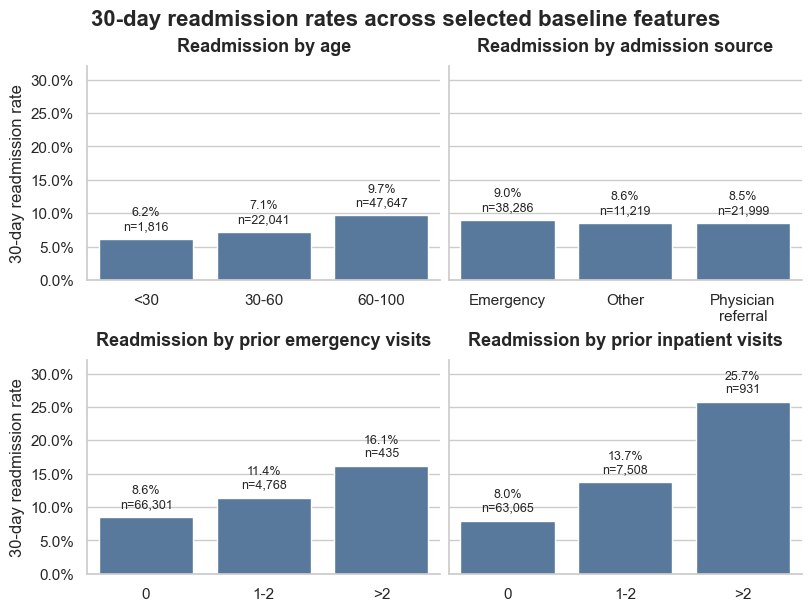

In [16]:
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib.ticker import PercentFormatter
from textwrap import fill

sns.set_theme(style="whitegrid", context="notebook")

eda_df = X_initial_model.copy()
eda_df["readmitted_30"] = y_initial

# Target balance after the initial cleaning steps.
target_summary = eda_df["readmitted_30"].value_counts().rename(
    index={0: "No 30-day readmission", 1: "30-day readmission"}
).to_frame("records")
target_summary["proportion"] = target_summary["records"] / target_summary["records"].sum()
display(target_summary)


def readmission_summary(column):
    return (
        eda_df.groupby(column, observed=True)["readmitted_30"]
        .agg(records="size", readmission_rate="mean")
        .sort_values("readmission_rate", ascending=False)
    )


summary_columns = [
    "age_group",
    "race_group",
    "admission_source_group",
    "diag_1_group",
    "number_outpatient_group",
    "number_emergency_group",
    "number_inpatient_group",
]

for column in summary_columns:
    print(f"Readmission summary by {column}")
    display(readmission_summary(column))

plot_orders = {
    "age_group": ["<30", "30-60", "60-100"],
    "number_outpatient_group": ["0", "1-2", ">2"],
    "number_emergency_group": ["0", "1-2", ">2"],
    "number_inpatient_group": ["0", "1-2", ">2"],
}

plot_specs = [
    ("age_group", "Readmission by age"),
    ("admission_source_group", "Readmission by admission source"),
    ("number_emergency_group", "Readmission by prior emergency visits"),
    ("number_inpatient_group", "Readmission by prior inpatient visits"),
]

fig, axes = plt.subplots(2, 2, figsize=(8, 6), sharey=True, constrained_layout=True)
axes = axes.ravel()

for index, (ax, (column, title)) in enumerate(zip(axes, plot_specs)):
    summary = readmission_summary(column).reset_index()

    if column in plot_orders:
        ordered_values = [value for value in plot_orders[column] if value in summary[column].values]
        summary[column] = pd.Categorical(summary[column], categories=ordered_values, ordered=True)
        summary = summary.sort_values(column)
    else:
        summary = summary.sort_values("readmission_rate", ascending=False)

    sns.barplot(
        data=summary,
        x=column,
        y="readmission_rate",
        ax=ax,
        color="#4C78A8",
        edgecolor="white",
    )

    ax.set_title(title, fontsize=13, weight="bold", pad=10)
    ax.set_xlabel("")
    ax.set_ylabel("30-day readmission rate" if index % 2 == 0 else "")
    ax.yaxis.set_major_formatter(PercentFormatter(1.0))
    ax.set_ylim(0, max(0.30, summary["readmission_rate"].max() * 1.25))

    tick_positions = ax.get_xticks()
    labels = [fill(str(label.get_text()), width=14) for label in ax.get_xticklabels()]
    ax.set_xticks(tick_positions)
    ax.set_xticklabels(labels, rotation=0, ha="center")

    for patch, (_, row) in zip(ax.patches, summary.iterrows()):
        ax.text(
            patch.get_x() + patch.get_width() / 2,
            patch.get_height() + 0.01,
            f"{row['readmission_rate']:.1%}\nn={int(row['records']):,}",
            ha="center",
            va="bottom",
            fontsize=9,
        )

    sns.despine(ax=ax)

fig.suptitle(
    "30-day readmission rates across selected baseline features",
    fontsize=16,
    weight="bold",
)
plt.show()


In [17]:
# The reusable preparation helper creates one-hot encoded model inputs.
# For now, each categorical variable drops one level to avoid redundant dummy columns.

print(X_initial_model.shape)
print(X_initial_encoded.shape)
display(X_initial_encoded.head())


(71504, 9)
(71504, 37)


,age_group_30-60,age_group_60-100,age_group_<30,race_group_African American,race_group_Caucasian,race_group_Other,gender_Female,gender_Male,admission_type_id_1,admission_type_id_2,...,diag_1_group_Respiratory,number_outpatient_group_0,number_outpatient_group_1-2,number_outpatient_group_>2,number_emergency_group_0,number_emergency_group_1-2,number_emergency_group_>2,number_inpatient_group_0,number_inpatient_group_1-2,number_inpatient_group_>2
8,0,1,0,0,1,0,1,0,0,1,...,0,1,0,0,1,0,0,1,0,0
9,0,1,0,0,1,0,1,0,0,0,...,0,1,0,0,1,0,0,1,0,0
4,1,0,0,0,1,0,0,1,1,0,...,0,1,0,0,1,0,0,1,0,0
10,1,0,0,1,0,0,1,0,1,0,...,0,1,0,0,1,0,0,1,0,0
5,1,0,0,0,1,0,0,1,0,1,...,0,1,0,0,1,0,0,1,0,0


### Feature-target correlation check before splitting

Before creating the train/test split, we can inspect whether any cleaned baseline feature has a strong marginal association with the target. Because the model inputs are categorical, this check one-hot encodes all categories without dropping a reference level and then computes the Pearson correlation between each category indicator and `readmitted_30`. For binary indicators and a binary target, this is equivalent to a phi correlation. These are univariate EDA checks only; they do not capture interactions or prove predictive value.


,correlation,absolute_correlation,strength
number_inpatient_group_0,-0.080266,0.080266,weak
number_inpatient_group_>2,0.068416,0.068416,weak
number_inpatient_group_1-2,0.059176,0.059176,weak
age_group_60-100,0.043345,0.043345,very weak
age_group_30-60,-0.039152,0.039152,very weak
number_emergency_group_0,-0.029696,0.029696,very weak
number_emergency_group_1-2,0.024640,0.024640,very weak
diag_1_group_Respiratory,-0.024302,0.024302,very weak
number_emergency_group_>2,0.020145,0.020145,very weak
diag_1_group_Injury,0.016948,0.016948,very weak


No baseline feature category has an absolute correlation >= 0.10 with readmitted_30.


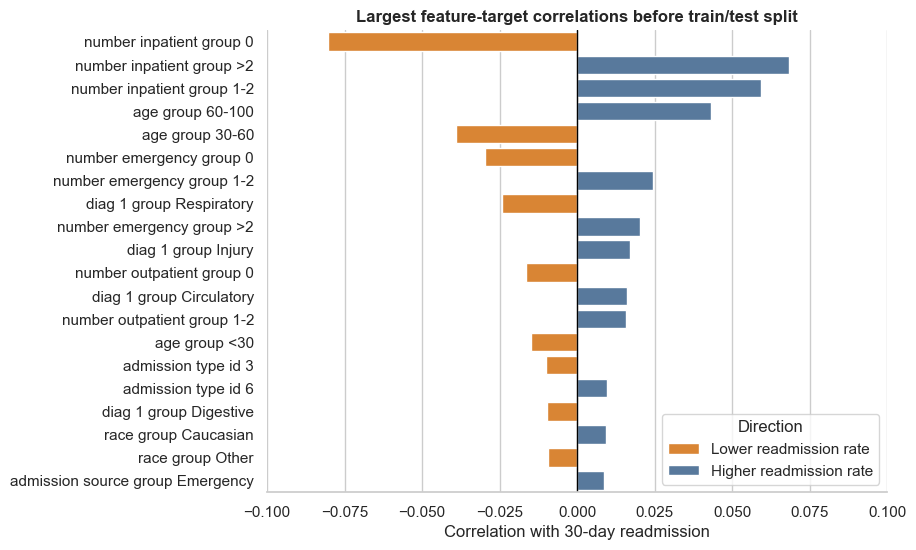

In [18]:
# Check marginal feature-target correlations before the train/test split.
# Use all category indicators here so the EDA is easier to interpret.
correlation_features = pd.get_dummies(
    X_initial_model,
    columns=BASE_CATEGORICAL_COLUMNS,
    drop_first=False,
    dtype=int,
)

feature_target_correlations = (
    correlation_features.corrwith(y_initial)
    .dropna()
    .to_frame("correlation")
)
feature_target_correlations["absolute_correlation"] = feature_target_correlations["correlation"].abs()
feature_target_correlations = feature_target_correlations.sort_values(
    "absolute_correlation",
    ascending=False,
)

top_feature_target_correlations = feature_target_correlations.head(20).copy()
top_feature_target_correlations["strength"] = pd.cut(
    top_feature_target_correlations["absolute_correlation"],
    bins=[0, 0.05, 0.10, 0.20, 1.00],
    labels=["very weak", "weak", "moderate", "strong"],
    include_lowest=True,
)

display(top_feature_target_correlations)

strong_correlation_threshold = 0.10
strong_correlations = feature_target_correlations.loc[
    feature_target_correlations["absolute_correlation"] >= strong_correlation_threshold
]

if strong_correlations.empty:
    print(
        f"No baseline feature category has an absolute correlation >= "
        f"{strong_correlation_threshold:.2f} with readmitted_30."
    )
else:
    print(
        f"Feature categories with absolute correlation >= "
        f"{strong_correlation_threshold:.2f}:"
    )
    display(strong_correlations)

plot_correlation_df = top_feature_target_correlations.reset_index().rename(columns={"index": "feature"})
plot_correlation_df["display_feature"] = plot_correlation_df["feature"].str.replace("_", " ").map(
    lambda value: fill(value, width=34)
)
plot_correlation_df["direction"] = np.where(
    plot_correlation_df["correlation"] >= 0,
    "Higher readmission rate",
    "Lower readmission rate",
)

fig, ax = plt.subplots(figsize=(8, 6))
sns.barplot(
    data=plot_correlation_df,
    y="display_feature",
    x="correlation",
    hue="direction",
    dodge=False,
    palette={"Higher readmission rate": "#4C78A8", "Lower readmission rate": "#F58518"},
    ax=ax,
)
ax.axvline(0, color="black", linewidth=1)
axis_limit = max(0.10, plot_correlation_df["correlation"].abs().max() * 1.15)
ax.set_xlim(-axis_limit, axis_limit)
ax.set_title("Largest feature-target correlations before train/test split", weight="bold")
ax.set_xlabel("Correlation with 30-day readmission")
ax.set_ylabel("")
ax.legend(title="Direction", loc="lower right")
sns.despine(ax=ax, left=True)
plt.show()


## 4. Train test split

For the train-test split, we have to stratify the splitting because the target variable is imbalanced. Only about 10% are re-admitted within 30 days from discharge.


In [19]:
from sklearn.model_selection import train_test_split

# Perform a stratified train-test split to maintain the target variable distribution.
X_train, X_test, y_train, y_test = train_test_split(X_initial_encoded, y_initial, test_size=0.2, random_state=42,
                                                    stratify=y_initial)

print(X_train.shape, y_train.shape)
print(X_test.shape, y_test.shape)
print(y_train.value_counts(normalize=True).rename("proportion"))
print(y_test.value_counts(normalize=True).rename("proportion"))

(57203, 37) (57203,)
(14301, 37) (14301,)
readmitted_30
0    0.912015
1    0.087985
Name: proportion, dtype: float64
readmitted_30
0    0.912034
1    0.087966
Name: proportion, dtype: float64


## 5. Logistic regression model as a baseline

To start with, we will use the logistic regression model to see how predictive these variables are of readmission.

              precision    recall  f1-score   support

           0       0.93      0.58      0.72     13043
           1       0.11      0.54      0.18      1258

    accuracy                           0.58     14301
   macro avg       0.52      0.56      0.45     14301
weighted avg       0.86      0.58      0.67     14301



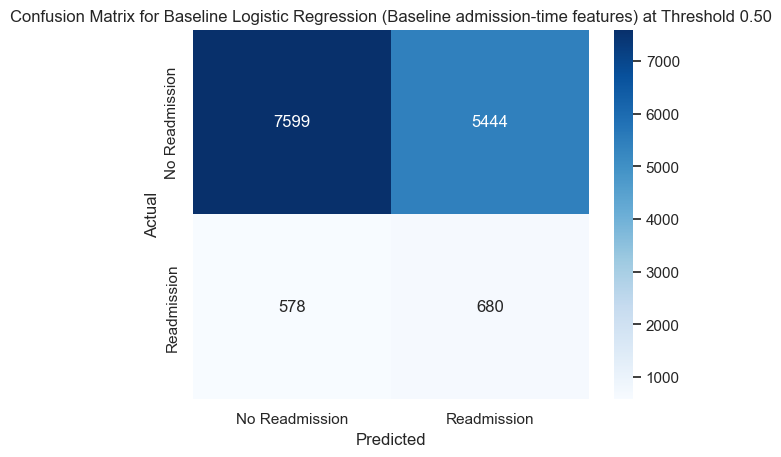

Test ROC-AUC: 0.592
Test average precision: 0.129


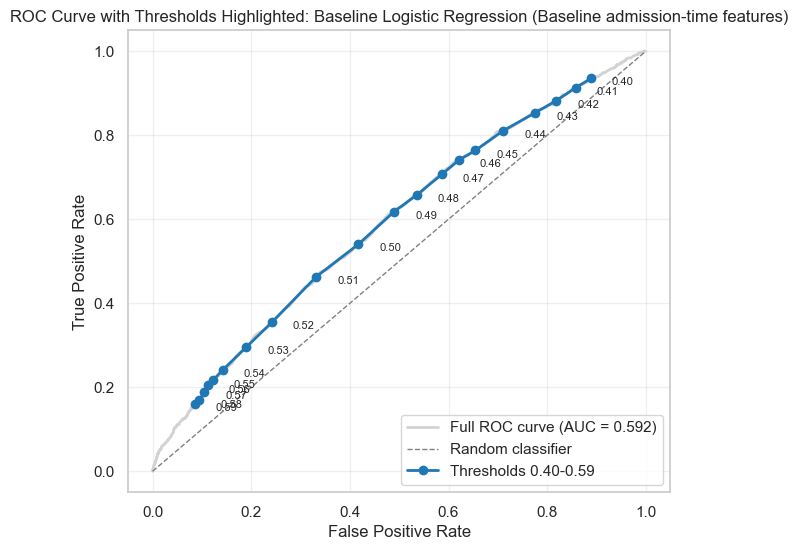

,threshold,fpr,tpr
0,0.40,0.889059,0.935612
1,0.41,0.858391,0.913355
2,0.42,0.818370,0.882353
3,0.43,0.776048,0.853736
4,0.44,0.710879,0.810811
5,0.45,0.654604,0.763911
6,0.46,0.621253,0.740859
7,0.47,0.586138,0.706677
8,0.48,0.536073,0.658188
9,0.49,0.489995,0.618442


In [20]:
from sklearn.linear_model import LogisticRegression

from src.model_evaluation import evaluate_model

baseline_logistic_model = LogisticRegression(
    max_iter=1000,
    random_state=42,
    class_weight="balanced",
    C=1,
)

baseline_results = evaluate_model(
    baseline_logistic_model,
    X_train,
    y_train,
    X_test,
    y_test,
    model_name=f"Baseline Logistic Regression ({BASELINE_FEATURE_SET})",
)


Best parameters: {'model__C': 0.1, 'model__class_weight': 'balanced', 'model__max_iter': 10000, 'model__solver': 'lbfgs', 'model__tol': 0.0001}
Best cross-validation score: 0.13003811549019392
Selected threshold by validation balanced_accuracy: 0.48


,threshold,f1,precision,recall,specificity,balanced_accuracy
0,0.30,0.161858,0.088055,1.000000,0.000479,0.500240
1,0.31,0.161910,0.088086,1.000000,0.000863,0.500431
2,0.32,0.162119,0.088210,1.000000,0.002396,0.501198
3,0.33,0.162127,0.088222,0.999007,0.003546,0.501277
4,0.34,0.162894,0.088693,0.997021,0.011309,0.504165
5,0.35,0.163558,0.089086,0.997021,0.016101,0.506561
6,0.36,0.165918,0.090546,0.990070,0.040253,0.515161
7,0.37,0.165993,0.090691,0.978153,0.053479,0.515816
8,0.38,0.166309,0.091011,0.963257,0.071497,0.517377
9,0.39,0.167108,0.091711,0.939424,0.102070,0.520747


              precision    recall  f1-score   support

           0       0.93      0.47      0.63     13043
           1       0.11      0.65      0.18      1258

    accuracy                           0.49     14301
   macro avg       0.52      0.56      0.40     14301
weighted avg       0.86      0.49      0.59     14301



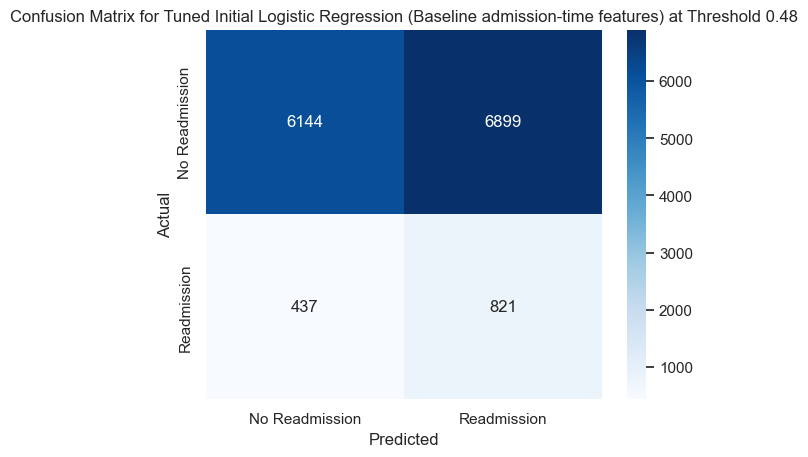

Test ROC-AUC: 0.593
Test average precision: 0.130


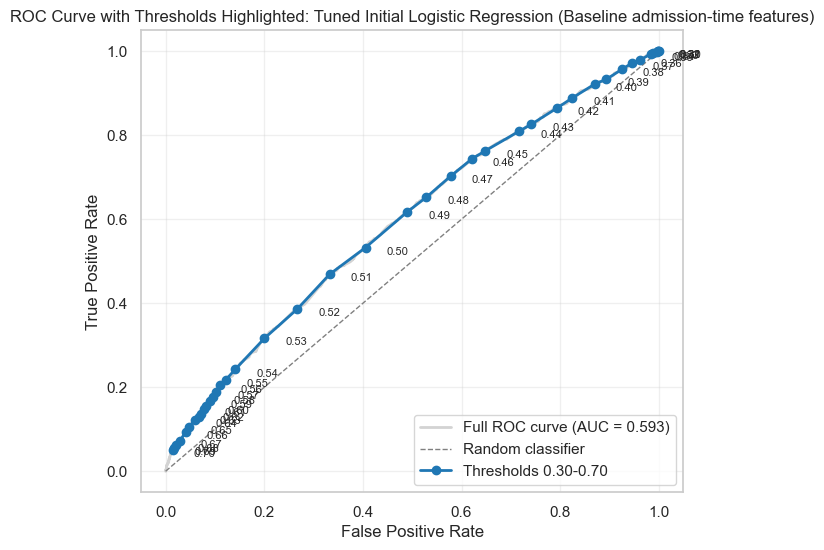

,threshold,fpr,tpr
0,0.30,0.999770,1.000000
1,0.31,0.999233,1.000000
2,0.32,0.997853,1.000000
3,0.33,0.996473,0.997615
4,0.34,0.988346,0.995231
5,0.35,0.983286,0.993641
6,0.36,0.962049,0.978537
7,0.37,0.945028,0.971383
8,0.38,0.925401,0.957075
9,0.39,0.893659,0.933227


In [21]:
# Tune around the balanced logistic-regression baseline.
# evaluate_model uses stratified GridSearchCV folds and average precision by default.
initial_logistic_param_grid = {
    "model__solver": ["lbfgs"],
    "model__C": [0.003, 0.005, 0.01, 0.015, 0.02, 0.03, 0.05, 0.1],
    "model__class_weight": ["balanced"],
    "model__max_iter": [10000],
    "model__tol": [1e-4],
}

initial_tuned_results = evaluate_model(
    LogisticRegression(random_state=42),
    X_train,
    y_train,
    X_test,
    y_test,
    model_name=f"Tuned Initial Logistic Regression ({BASELINE_FEATURE_SET})",
    param_grid=initial_logistic_param_grid,
    scoring="average_precision",
    threshold="best_balanced_accuracy",
    threshold_values=np.arange(0.30, 0.71, 0.01),
    plot_roc_auc=True,
)


The model evaluation helper now handles the threshold-dependent confusion matrix and can optionally plot the ROC curve with selected thresholds highlighted. For tuned models, GridSearchCV uses stratified cross-validation and average precision by default because the readmission target is imbalanced. When a threshold-search mode is requested, the operating threshold is selected on a validation slice of the training data and then applied once to the test set.

In [22]:
# The tuned model call above sets plot_roc_auc=True, so the ROC-AUC chart and
# threshold table are generated as part of the shared evaluation helper.
initial_tuned_results["threshold_points"]


,threshold,fpr,tpr
0,0.30,0.999770,1.000000
1,0.31,0.999233,1.000000
2,0.32,0.997853,1.000000
3,0.33,0.996473,0.997615
4,0.34,0.988346,0.995231
5,0.35,0.983286,0.993641
6,0.36,0.962049,0.978537
7,0.37,0.945028,0.971383
8,0.38,0.925401,0.957075
9,0.39,0.893659,0.933227


ROC-AUC measures how well the model ranks patients by risk across all classification thresholds. Average precision is the primary model-selection metric because it focuses on positive-class ranking under class imbalance. Threshold-dependent metrics such as F1, recall, specificity, and balanced accuracy are still reported after selecting an operating threshold.

## 6. Additional features and further model exploration

The next stage will explore whether HbA1c-related information (`A1Cresult`) and glucose-related information (`max_glu_serum`) improve predictive performance. These variables were excluded from the first admission-focused baseline because it is not clear whether they would be known at the exact time of admission. However, they are central to the project question and to the published paper, so they should be examined in EDA and then considered in an expanded clinical model.

This expanded model intentionally changes the modeling question from admission-time prediction to discharge-time prediction. That means variables known by discharge, including `time_in_hospital`, can be included. The published paper also excluded patients whose discharge status made ordinary readmission analysis inappropriate, including deaths and hospice-related discharges. In the UCI coding scheme, these are commonly represented by discharge disposition IDs `11`, `13`, `14`, `19`, `20`, and `21`. These records should be excluded in a paper-style analysis because patients who died or were discharged to hospice are not comparable to patients who remained at risk for standard hospital readmission.

Therefore, before fitting the discharge-time model, the cohort definition is made explicit: remove death and hospice-related discharge dispositions to more closely match the paper-style analysis cohort, then compare models on the same cohort and train/test split.

### Fair comparison setup

The expanded analysis changes the prediction time point to discharge, removes death/hospice-related discharge dispositions, and adds discharge-time features including HbA1c/glucose results, stay length, and whether diabetes medication was changed during the encounter. To interpret the metric changes, we compare models on the same paper-style cohort and the same train/test split: one with the baseline feature set only, and one with the added discharge-time features.


Rows before exclusion: 71,518
Rows after exclusion: 69,973
Rows removed: 1,545


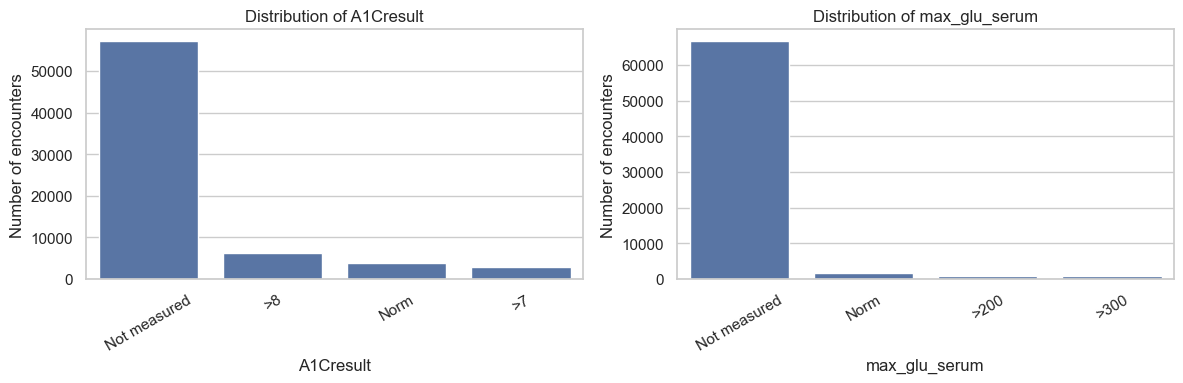

In [23]:
# Remove death and hospice-related discharge dispositions for a paper-style expanded cohort.
# These patients are not comparable to patients who remain at risk for standard readmission.
df_expanded = df_first.loc[
    ~df_first["discharge_disposition_id"].isin(DEATH_OR_HOSPICE_DISCHARGE_IDS)
].copy()

print(f"Rows before exclusion: {len(df_first):,}")
print(f"Rows after exclusion: {len(df_expanded):,}")
print(f"Rows removed: {len(df_first) - len(df_expanded):,}")

# A1Cresult and max_glu_serum are categorical lab-result variables in this dataset.
# Use count histograms to inspect their distributions.
lab_columns = ["A1Cresult", "max_glu_serum"]
lab_plot_df = df_expanded[lab_columns].fillna("Not measured")

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

for ax, column in zip(axes, lab_columns):
    order = lab_plot_df[column].value_counts().index
    sns.countplot(data=lab_plot_df, x=column, order=order, ax=ax)
    ax.set_title(f"Distribution of {column}")
    ax.set_xlabel(column)
    ax.set_ylabel("Number of encounters")
    ax.tick_params(axis="x", rotation=30)

plt.tight_layout()
plt.show()


From the histograms above, we can see that the majority of the patients did not have their HbA1c level measured, and neither did they have the maximum glucose in serum measured. However, those who had, have been categorised, so we have:
- not measured
- normal
- more than 7 but less than 8
- more than 8

Similarly, for glucose, we have:
- not measured normal
- more than 200
- more than 300
This will allow us to create new categorical variables that will be hot encoded for further analysis.

Let's investigate the rates of readmission in the HbA1c groups.

,A1Cresult_group,records,readmission_rate
0,Not measured,57128,0.091006
1,Norm,3741,0.086341
2,>7,2865,0.085864
3,>8,6239,0.081584


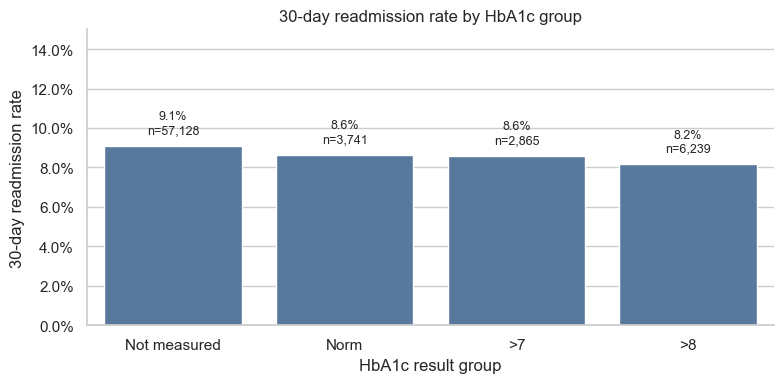

In [24]:
a1c_readmission_df = df_expanded.copy()
a1c_readmission_df["A1Cresult_group"] = a1c_readmission_df["A1Cresult"].fillna("Not measured")
a1c_readmission_df["readmitted_30"] = encode_readmitted_30(a1c_readmission_df["readmitted"])

a1c_group_order = ["Not measured", "Norm", ">7", ">8"]
a1c_readmission_summary = (
    a1c_readmission_df.groupby("A1Cresult_group", observed=True)["readmitted_30"]
    .agg(records="size", readmission_rate="mean")
    .reindex(a1c_group_order)
    .dropna(subset=["records"])
    .reset_index()
)

display(a1c_readmission_summary)

fig, ax = plt.subplots(figsize=(8, 4))
sns.barplot(
    data=a1c_readmission_summary,
    x="A1Cresult_group",
    y="readmission_rate",
    order=a1c_readmission_summary["A1Cresult_group"],
    color="#4C78A8",
    edgecolor="white",
    ax=ax,
)

ax.set_title("30-day readmission rate by HbA1c group")
ax.set_xlabel("HbA1c result group")
ax.set_ylabel("30-day readmission rate")
ax.yaxis.set_major_formatter(PercentFormatter(1.0))
ax.set_ylim(0, max(0.15, a1c_readmission_summary["readmission_rate"].max() * 1.25))

for patch, (_, row) in zip(ax.patches, a1c_readmission_summary.iterrows()):
    ax.text(
        patch.get_x() + patch.get_width() / 2,
        patch.get_height() + 0.005,
        f"{row['readmission_rate']:.1%}\nn={int(row['records']):,}",
        ha="center",
        va="bottom",
        fontsize=9,
    )

sns.despine(ax=ax)
plt.tight_layout()
plt.show()


Because this section is now a discharge-time prediction experiment, we can include length of stay. Let's investigate the length of stay in hospital.

time_in_hospital
3     12701
2     12397
1     10717
4      9567
5      6839
6      5171
7      3999
8      2919
9      1990
10     1558
11     1241
12      955
13      795
14      669
Name: count, dtype: int64


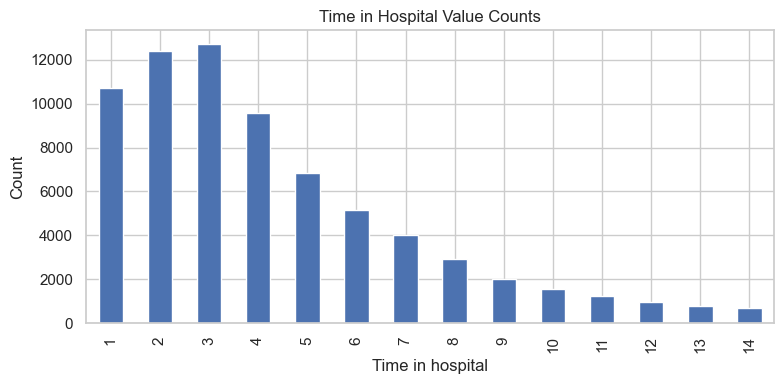

In [25]:
print(df_first['time_in_hospital'].value_counts())

time_in_hospital_counts = df_first['time_in_hospital'].value_counts().sort_index()
fig, ax = plt.subplots(figsize=(8, 4))
time_in_hospital_counts.plot(kind='bar', ax=ax)
ax.set_title('Time in Hospital Value Counts')
ax.set_xlabel('Time in hospital')
ax.set_ylabel('Count')
plt.tight_layout()
plt.show()


The time in hospital has values from 1 to 14 days. For the discharge-time model, it is grouped into three ordered categories: 1-3 days, 4-7 days, and 8-14 days. A helper function has been added in section 3 above.

In [26]:
# Build paper-style baseline and expanded discharge-time modeling dataframes on the same cohort.
# This allows a fair comparison between baseline features and added discharge-time features.
# The `change` feature indicates whether diabetes medication changed during the encounter.

X_paper_baseline, X_paper_baseline_model, X_paper_baseline_encoded, y_paper_baseline = prepare_model_data(
    df_expanded,
    raw_feature_columns=BASE_RAW_FEATURE_COLUMNS,
    model_columns=BASE_MODEL_COLUMNS,
    categorical_columns=BASE_CATEGORICAL_COLUMNS,
    feature_builders=initial_feature_builders,
)

expanded_raw_feature_columns = BASE_RAW_FEATURE_COLUMNS + [
    "time_in_hospital",
    "A1Cresult",
    "max_glu_serum",
    "change",
]

expanded_model_variables = BASE_MODEL_COLUMNS + [
    "stay_length_group",
    "A1Cresult_group",
    "max_glu_serum_group",
    "change",
]

expanded_categorical_columns = BASE_CATEGORICAL_COLUMNS + [
    "stay_length_group",
    "A1Cresult_group",
    "max_glu_serum_group",
    "change",
]

expanded_feature_builders = initial_feature_builders + [
    add_lab_result_groups,
    add_stay_length_group,
]

X_expanded, X_expanded_model, X_expanded_encoded, y_expanded = prepare_model_data(
    df_expanded,
    raw_feature_columns=expanded_raw_feature_columns,
    model_columns=expanded_model_variables,
    categorical_columns=expanded_categorical_columns,
    feature_builders=expanded_feature_builders,
)

assert y_paper_baseline.index.equals(y_expanded.index)

print("Paper-style baseline encoded shape:", X_paper_baseline_encoded.shape)
print("Expanded encoded shape:", X_expanded_encoded.shape)
print("Target shape:", y_expanded.shape)
display(X_expanded_model.head())
display(X_expanded_encoded.head())
display(y_expanded.value_counts(normalize=True).rename("proportion"))


Paper-style baseline encoded shape: (69960, 37)
Expanded encoded shape: (69960, 50)
Target shape: (69960,)


,age_group,race_group,gender,admission_type_id,admission_source_group,diag_1_group,number_outpatient_group,number_emergency_group,number_inpatient_group,stay_length_group,A1Cresult_group,max_glu_serum_group,change
8,60-100,Caucasian,Female,2,Other,Circulatory,0,0,0,long_8_14,Not measured,Not measured,Ch
9,60-100,Caucasian,Female,3,Other,Circulatory,0,0,0,long_8_14,Not measured,Not measured,Ch
4,30-60,Caucasian,Male,1,Emergency,Neoplasms,0,0,0,short_1_3,Not measured,Not measured,Ch
10,30-60,African American,Female,1,Emergency,Diabetes,0,0,0,long_8_14,Not measured,Not measured,No
5,30-60,Caucasian,Male,2,Other,Circulatory,0,0,0,short_1_3,Not measured,Not measured,No


,age_group_30-60,age_group_60-100,age_group_<30,race_group_African American,race_group_Caucasian,race_group_Other,gender_Female,gender_Male,admission_type_id_1,admission_type_id_2,...,A1Cresult_group_>7,A1Cresult_group_>8,A1Cresult_group_Norm,A1Cresult_group_Not measured,max_glu_serum_group_>200,max_glu_serum_group_>300,max_glu_serum_group_Norm,max_glu_serum_group_Not measured,change_Ch,change_No
8,0,1,0,0,1,0,1,0,0,1,...,0,0,0,1,0,0,0,1,1,0
9,0,1,0,0,1,0,1,0,0,0,...,0,0,0,1,0,0,0,1,1,0
4,1,0,0,0,1,0,0,1,1,0,...,0,0,0,1,0,0,0,1,1,0
10,1,0,0,1,0,0,1,0,1,0,...,0,0,0,1,0,0,0,1,0,1
5,1,0,0,0,1,0,0,1,0,1,...,0,0,0,1,0,0,0,1,0,1


readmitted_30
0    0.910306
1    0.089694
Name: proportion, dtype: float64

Best parameters: {'model__C': 0.1, 'model__class_weight': 'balanced', 'model__max_iter': 10000, 'model__solver': 'lbfgs', 'model__tol': 0.0001}
Best cross-validation score: 0.13312395640357116
Selected threshold by validation balanced_accuracy: 0.49


,threshold,f1,precision,recall,specificity,balanced_accuracy
0,0.30,0.164712,0.089747,1.000000,0.000687,0.500343
1,0.31,0.164588,0.089682,0.999004,0.000883,0.499944
2,0.32,0.164669,0.089730,0.999004,0.001472,0.500238
3,0.33,0.164785,0.089823,0.996016,0.005594,0.500805
4,0.34,0.164807,0.089860,0.993028,0.009028,0.501028
5,0.35,0.165414,0.090279,0.986056,0.021001,0.503528
6,0.36,0.165788,0.090630,0.971116,0.039941,0.505528
7,0.37,0.166524,0.091114,0.966135,0.050442,0.508289
8,0.38,0.167986,0.092128,0.951195,0.076447,0.513821
9,0.39,0.168758,0.092856,0.924303,0.110304,0.517304


              precision    recall  f1-score   support

           0       0.93      0.53      0.67     12737
           1       0.11      0.57      0.18      1255

    accuracy                           0.53     13992
   macro avg       0.52      0.55      0.43     13992
weighted avg       0.85      0.53      0.63     13992



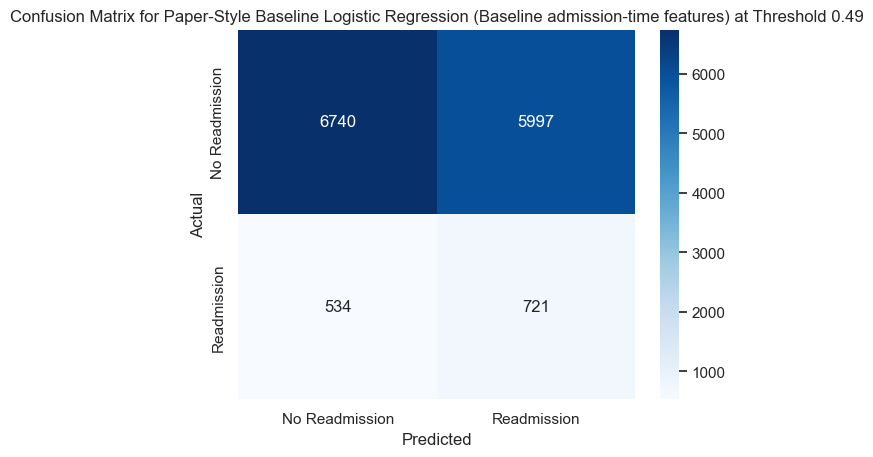

Test ROC-AUC: 0.586
Test average precision: 0.128


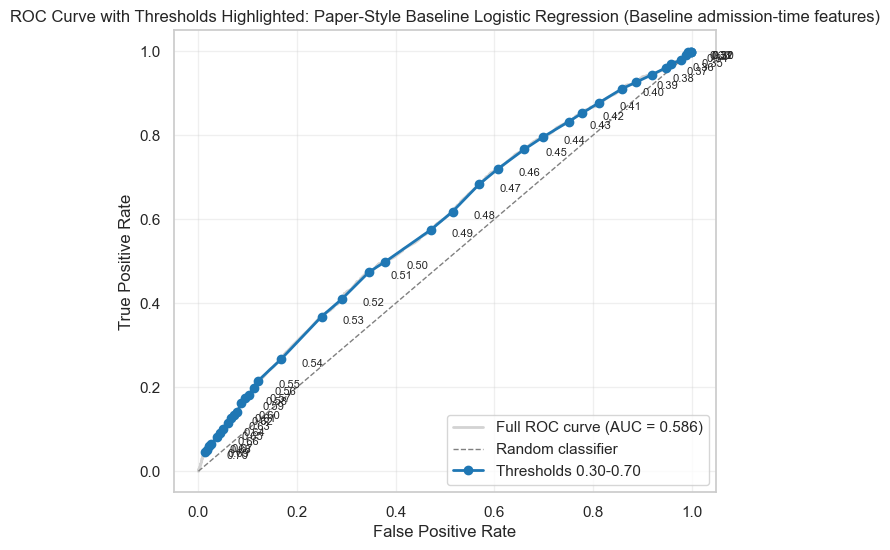

,threshold,fpr,tpr
0,0.30,0.999450,0.998406
1,0.31,0.998744,0.998406
2,0.32,0.997802,0.998406
3,0.33,0.993719,0.997610
4,0.34,0.988694,0.992032
5,0.35,0.978095,0.978486
6,0.36,0.959253,0.970518
7,0.37,0.948339,0.960956
8,0.38,0.919761,0.944223
9,0.39,0.886551,0.925896


Best parameters: {'model__C': 0.1, 'model__class_weight': 'balanced', 'model__max_iter': 10000, 'model__solver': 'lbfgs', 'model__tol': 0.0001}
Best cross-validation score: 0.13676437299435903
Selected threshold by validation balanced_accuracy: 0.49


,threshold,f1,precision,recall,specificity,balanced_accuracy
0,0.30,0.164977,0.089929,0.997012,0.005888,0.501450
1,0.31,0.165110,0.090024,0.995020,0.009028,0.502024
2,0.32,0.165543,0.090323,0.990040,0.017566,0.503803
3,0.33,0.166554,0.090976,0.984064,0.031207,0.507635
4,0.34,0.167764,0.091759,0.977092,0.047105,0.512098
5,0.35,0.168494,0.092314,0.964143,0.065947,0.515045
6,0.36,0.170805,0.093750,0.959163,0.086457,0.522810
7,0.37,0.170816,0.093981,0.936255,0.110697,0.523476
8,0.38,0.172494,0.095102,0.926295,0.131600,0.528947
9,0.39,0.174195,0.096312,0.910359,0.158391,0.534375


              precision    recall  f1-score   support

           0       0.93      0.58      0.71     12737
           1       0.11      0.56      0.19      1255

    accuracy                           0.57     13992
   macro avg       0.52      0.57      0.45     13992
weighted avg       0.86      0.57      0.67     13992



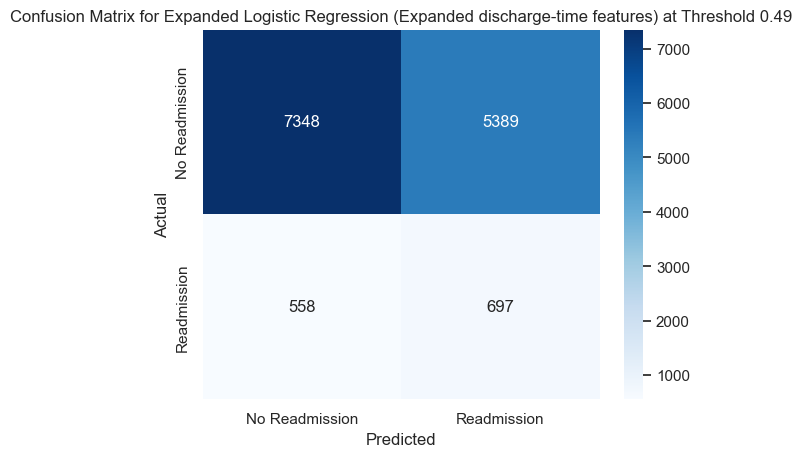

Test ROC-AUC: 0.590
Test average precision: 0.129


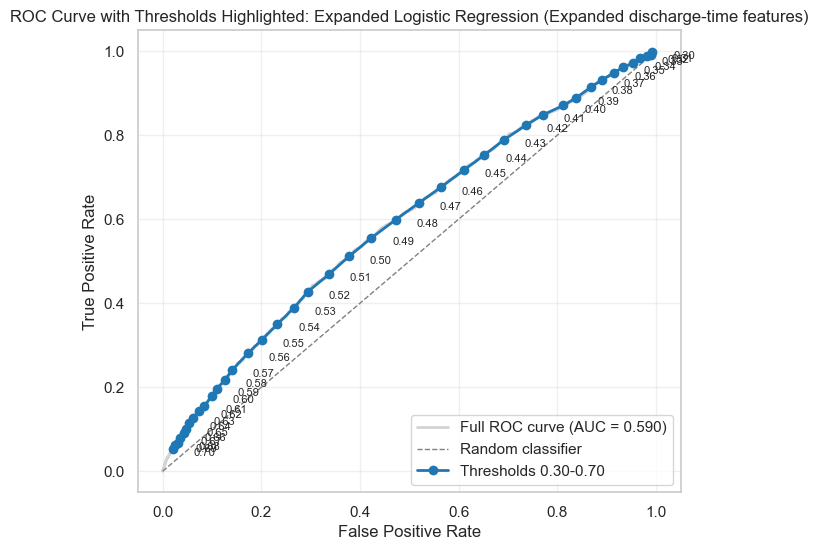

,threshold,fpr,tpr
0,0.30,0.993170,0.997610
1,0.31,0.989401,0.992032
2,0.32,0.981942,0.989641
3,0.33,0.968831,0.983267
4,0.34,0.954306,0.971315
5,0.35,0.933422,0.961753
6,0.36,0.914501,0.948207
7,0.37,0.891733,0.932271
8,0.38,0.867630,0.913944
9,0.39,0.838502,0.889243


,model,feature_set,f1,precision,recall,specificity,balanced_accuracy,roc_auc,average_precision
0,Paper-style baseline logistic regression,Baseline admission-time features,0.180860,0.107324,0.574502,0.529167,0.551834,0.586419,0.128292
1,Expanded discharge-time logistic regression,Expanded discharge-time features,0.189892,0.114525,0.555378,0.576902,0.566140,0.590409,0.129145


In [27]:
# Define one stratified train-test split for both paper-style models.

expanded_train_index, expanded_test_index = train_test_split(
    y_expanded.index,
    test_size=0.2,
    random_state=42,
    stratify=y_expanded,
)

X_train_paper_baseline = X_paper_baseline_encoded.loc[expanded_train_index]
X_test_paper_baseline = X_paper_baseline_encoded.loc[expanded_test_index]
y_train_expanded = y_expanded.loc[expanded_train_index]
y_test_expanded = y_expanded.loc[expanded_test_index]

X_train_expanded = X_expanded_encoded.loc[expanded_train_index]
X_test_expanded = X_expanded_encoded.loc[expanded_test_index]


def model_result_row(model_name, result, feature_set):
    return {
        "model": model_name,
        "feature_set": feature_set,
        **result["metrics"],
    }


def append_model_result(comparison, model_name, result, feature_set):
    return pd.concat(
        [comparison, pd.DataFrame([model_result_row(model_name, result, feature_set)])],
        ignore_index=True,
    )


expanded_logistic_param_grid = {
    "model__solver": ["lbfgs"],
    "model__C": [0.003, 0.005, 0.01, 0.02, 0.03, 0.05, 0.1],
    "model__class_weight": ["balanced"],
    "model__max_iter": [10000],
    "model__tol": [1e-4],
}

paper_baseline_tuned_results = evaluate_model(
    LogisticRegression(random_state=42),
    X_train_paper_baseline,
    y_train_expanded,
    X_test_paper_baseline,
    y_test_expanded,
    model_name=f"Paper-Style Baseline Logistic Regression ({BASELINE_FEATURE_SET})",
    param_grid=expanded_logistic_param_grid,
    scoring="average_precision",
    threshold="best_balanced_accuracy",
    threshold_values=np.arange(0.30, 0.71, 0.01),
    plot_roc_auc=True,
)

expanded_tuned_results = evaluate_model(
    LogisticRegression(random_state=42),
    X_train_expanded,
    y_train_expanded,
    X_test_expanded,
    y_test_expanded,
    model_name=f"Expanded Logistic Regression ({EXPANDED_FEATURE_SET})",
    param_grid=expanded_logistic_param_grid,
    scoring="average_precision",
    threshold="best_balanced_accuracy",
    threshold_values=np.arange(0.30, 0.71, 0.01),
    plot_roc_auc=True,
)

model_comparison = pd.DataFrame([
    model_result_row(
        "Paper-style baseline logistic regression",
        paper_baseline_tuned_results,
        BASELINE_FEATURE_SET,
    ),
    model_result_row(
        "Expanded discharge-time logistic regression",
        expanded_tuned_results,
        EXPANDED_FEATURE_SET,
    ),
])

display(model_comparison)


## 6a. Logistic regression with degree-2 polynomial features

The previous logistic regression models assume that each encoded feature contributes additively to the log-odds of 30-day readmission. To test whether simple feature interactions add useful signal, this section fits logistic regression after expanding the same one-hot encoded expanded feature matrix to degree-2 polynomial features.

The degree-2 expansion includes the original encoded columns and pairwise products. With one-hot encoded categorical variables, interactions between mutually exclusive categories can be all zeros in the training set, and any constant column can be absorbed by the intercept. Therefore, after creating the interaction-only polynomial features, columns that are all `0` or all `1` in the training set are removed. A second filter removes very rare generated columns that occur in less than 3% of the training rows, because those sparse interactions add dimensionality but are unlikely to estimate reliably. The test set is then restricted to the same retained columns, avoiding any feature-selection information from the test set.


Original expanded feature count: 50
Polynomial feature count before dropping all-zero/all-one columns: 1275
All-zero/all-one polynomial columns dropped: 142
Rare polynomial columns dropped: 667
Minimum count for retained polynomial columns: 1,680
Polynomial feature count after filtering: 466
Best parameters: {'model__C': 0.003, 'model__class_weight': 'balanced', 'model__max_iter': 10000, 'model__solver': 'lbfgs', 'model__tol': 0.0001}
Best cross-validation score: 0.1367758299483279
Selected threshold by validation balanced_accuracy: 0.51


,threshold,f1,precision,recall,specificity,balanced_accuracy
0,0.30,0.166540,0.090985,0.982072,0.033268,0.507670
1,0.31,0.167392,0.091537,0.977092,0.044553,0.510823
2,0.32,0.168793,0.092393,0.975100,0.056232,0.515666
3,0.33,0.170298,0.093314,0.973108,0.068400,0.520754
4,0.34,0.171146,0.093908,0.964143,0.083415,0.523779
5,0.35,0.171208,0.094099,0.948207,0.100589,0.524398
6,0.36,0.171319,0.094326,0.932271,0.118057,0.525164
7,0.37,0.172472,0.095130,0.922311,0.135623,0.528967
8,0.38,0.174170,0.096285,0.911355,0.157213,0.534284
9,0.39,0.175141,0.097063,0.895418,0.179293,0.537356


              precision    recall  f1-score   support

           0       0.93      0.65      0.76     12737
           1       0.12      0.47      0.19      1255

    accuracy                           0.64     13992
   macro avg       0.52      0.56      0.48     13992
weighted avg       0.85      0.64      0.71     13992



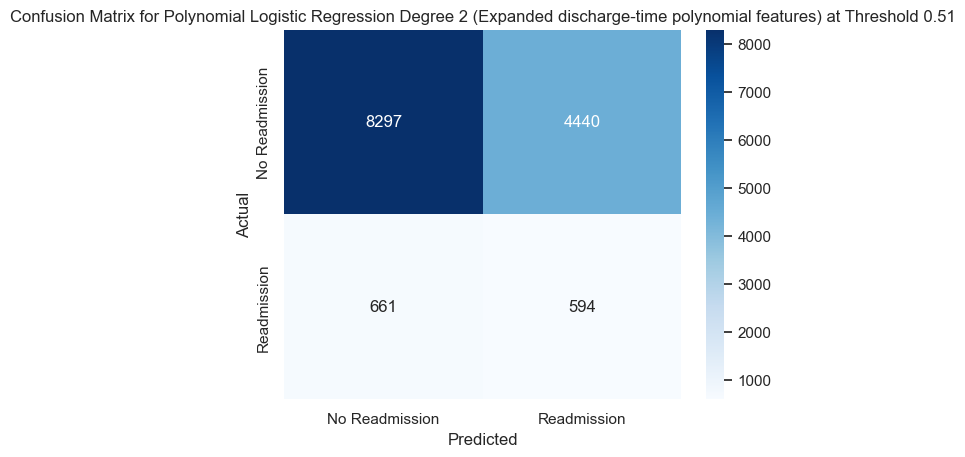

Test ROC-AUC: 0.590
Test average precision: 0.129


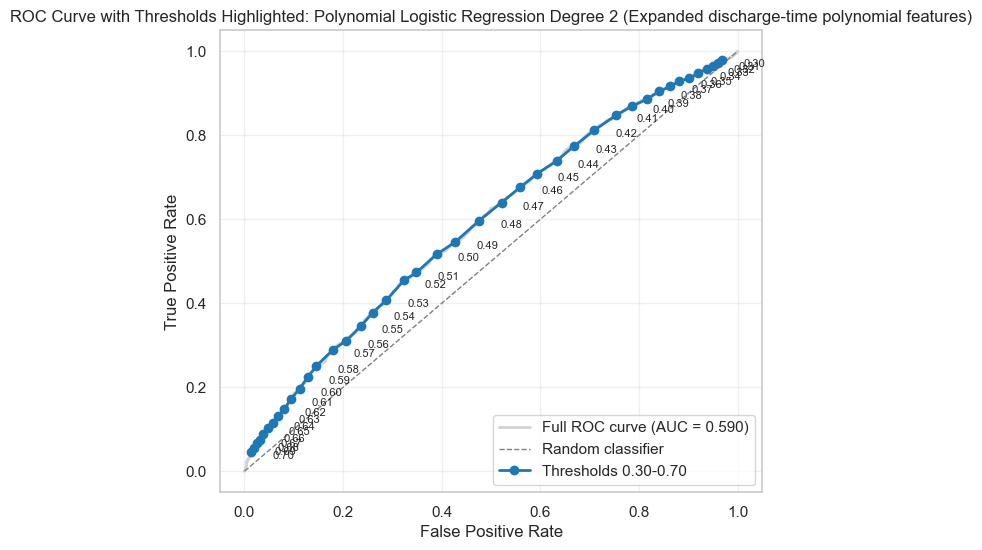

,threshold,fpr,tpr
0,0.30,0.969145,0.978486
1,0.31,0.960038,0.972908
2,0.32,0.949360,0.965737
3,0.33,0.936877,0.958566
4,0.34,0.920154,0.947410
5,0.35,0.901861,0.936255
6,0.36,0.881448,0.928287
7,0.37,0.863312,0.916335
8,0.38,0.840857,0.904382
9,0.39,0.815341,0.885259


,model,feature_set,f1,precision,recall,specificity,balanced_accuracy,roc_auc,average_precision
0,Paper-style baseline logistic regression,Baseline admission-time features,0.180860,0.107324,0.574502,0.529167,0.551834,0.586419,0.128292
1,Expanded discharge-time logistic regression,Expanded discharge-time features,0.189892,0.114525,0.555378,0.576902,0.566140,0.590409,0.129145
2,Polynomial logistic regression degree 2 at threshold 0.51,Expanded discharge-time polynomial features,0.188901,0.117998,0.473307,0.651409,0.562358,0.590237,0.129405


In [28]:
from sklearn.preprocessing import PolynomialFeatures

# Build degree-2 polynomial features from the expanded one-hot encoded feature matrix.
# All-zero/all-one and rare generated columns are detected only on the training set
# and removed from both splits.
polynomial_transformer = PolynomialFeatures(degree=2, interaction_only=True, include_bias=False)

X_train_polynomial_array = polynomial_transformer.fit_transform(X_train_expanded)
X_test_polynomial_array = polynomial_transformer.transform(X_test_expanded)
polynomial_feature_names = polynomial_transformer.get_feature_names_out(X_train_expanded.columns)

X_train_polynomial = pd.DataFrame(
    X_train_polynomial_array,
    columns=polynomial_feature_names,
    index=X_train_expanded.index,
)
X_test_polynomial = pd.DataFrame(
    X_test_polynomial_array,
    columns=polynomial_feature_names,
    index=X_test_expanded.index,
)

polynomial_column_sums = X_train_polynomial.sum(axis=0)
all_zero_or_one_polynomial_columns = X_train_polynomial.columns[
    (polynomial_column_sums == 0) | (polynomial_column_sums == len(X_train_polynomial))
]

X_train_polynomial_nonconstant = X_train_polynomial.drop(columns=all_zero_or_one_polynomial_columns)
X_test_polynomial_nonconstant = X_test_polynomial.loc[:, X_train_polynomial_nonconstant.columns]

minimum_polynomial_prevalence = 0.03
minimum_polynomial_count = int(np.ceil(minimum_polynomial_prevalence * len(X_train_polynomial_nonconstant)))
polynomial_nonconstant_sums = X_train_polynomial_nonconstant.sum(axis=0)
rare_polynomial_columns = X_train_polynomial_nonconstant.columns[
    polynomial_nonconstant_sums < minimum_polynomial_count
]

X_train_polynomial_reduced = X_train_polynomial_nonconstant.drop(columns=rare_polynomial_columns)
X_test_polynomial_reduced = X_test_polynomial_nonconstant.loc[:, X_train_polynomial_reduced.columns]

print("Original expanded feature count:", X_train_expanded.shape[1])
print("Polynomial feature count before dropping all-zero/all-one columns:", X_train_polynomial.shape[1])
print("All-zero/all-one polynomial columns dropped:", len(all_zero_or_one_polynomial_columns))
print("Rare polynomial columns dropped:", len(rare_polynomial_columns))
print(f"Minimum count for retained polynomial columns: {minimum_polynomial_count:,}")
print("Polynomial feature count after filtering:", X_train_polynomial_reduced.shape[1])

polynomial_logistic_param_grid = {
    "model__solver": ["lbfgs"],
    "model__C": [0.0003, 0.001, 0.003, 0.01],
    "model__class_weight": ["balanced"],
    "model__max_iter": [10000],
    "model__tol": [1e-4],
}

polynomial_logistic_results = evaluate_model(
    LogisticRegression(random_state=42),
    X_train_polynomial_reduced,
    y_train_expanded,
    X_test_polynomial_reduced,
    y_test_expanded,
    model_name=f"Polynomial Logistic Regression Degree 2 ({POLYNOMIAL_FEATURE_SET})",
    param_grid=polynomial_logistic_param_grid,
    scoring="average_precision",
    cv=5,
    n_jobs=1,
    threshold="best_balanced_accuracy",
    threshold_values=np.arange(0.30, 0.71, 0.01),
    plot_roc_auc=True,
)

polynomial_logistic_comparison = append_model_result(
    model_comparison,
    f"Polynomial logistic regression degree 2 at threshold {polynomial_logistic_results['selected_threshold']:.2f}",
    polynomial_logistic_results,
    POLYNOMIAL_FEATURE_SET,
)

display(polynomial_logistic_comparison)


## 7. Gradient boosted trees comparison

As a comparison to logistic regression, we fit a gradient boosted trees classifier on the same expanded feature matrix and the same train/test split. Tree boosting can capture nonlinear relationships and interactions between the encoded feature categories, so it is a useful next benchmark for this tabular readmission problem.

Because 30-day readmission is rare, a default probability threshold of `0.50` is too high for the boosted tree model. The model is tuned with average precision, which is appropriate for imbalanced data, and then the operating threshold is selected by balanced accuracy on a validation slice of the training data. That selected threshold is then applied once to the test set.


Training positive-class rate: 0.090
Best parameters: {'model__l2_regularization': 0.0, 'model__learning_rate': 0.1, 'model__max_iter': 300, 'model__max_leaf_nodes': 5, 'model__min_samples_leaf': 40}
Best cross-validation score: 0.13916927232307258
Selected threshold by validation balanced_accuracy: 0.09


,threshold,f1,precision,recall,specificity,balanced_accuracy
0,0.03,0.164631,0.089699,1.000000,0.000098,0.500049
1,0.04,0.165400,0.090180,0.997012,0.008930,0.502971
2,0.05,0.168856,0.092449,0.973108,0.058783,0.515945
3,0.06,0.174579,0.096447,0.919323,0.151423,0.535373
4,0.07,0.180295,0.101363,0.814741,0.288322,0.551531
5,0.08,0.188011,0.109182,0.676295,0.456330,0.566312
6,0.09,0.198257,0.119662,0.577689,0.581256,0.579473
7,0.10,0.201247,0.128325,0.466135,0.688027,0.577081
8,0.11,0.198478,0.145581,0.311753,0.819725,0.565739
9,0.12,0.191987,0.165230,0.229084,0.885967,0.557525


              precision    recall  f1-score   support

           0       0.93      0.57      0.71     12737
           1       0.11      0.56      0.19      1255

    accuracy                           0.57     13992
   macro avg       0.52      0.57      0.45     13992
weighted avg       0.86      0.57      0.66     13992



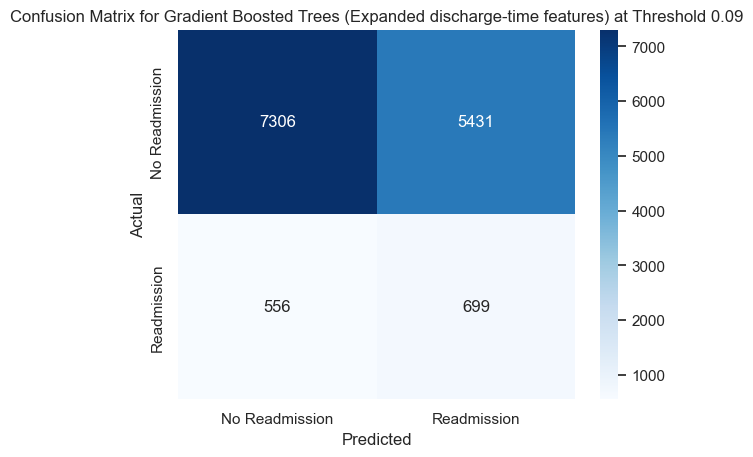

Test ROC-AUC: 0.592
Test average precision: 0.132


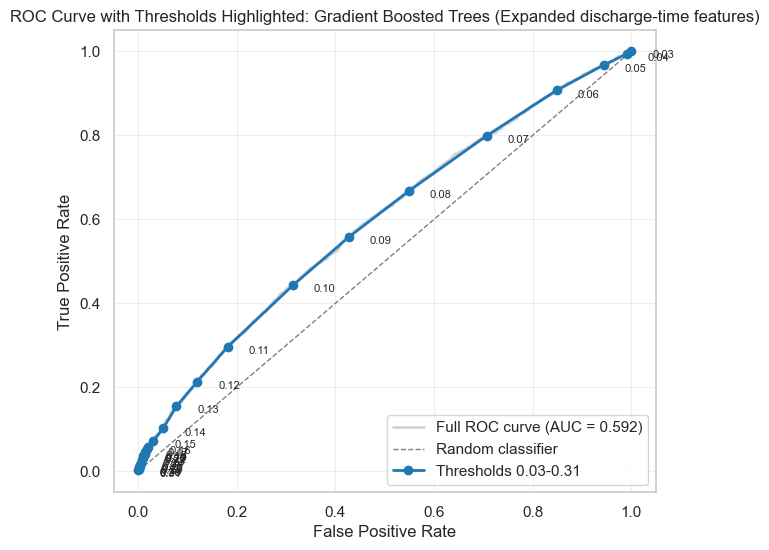

,threshold,fpr,tpr
0,0.03,0.999843,1.000000
1,0.04,0.990736,0.993625
2,0.05,0.943786,0.967331
3,0.06,0.848237,0.906773
4,0.07,0.706995,0.799203
5,0.08,0.548324,0.666932
6,0.09,0.426396,0.556972
7,0.10,0.313967,0.443028
8,0.11,0.181440,0.296414
9,0.12,0.119651,0.213546


,model,feature_set,f1,precision,recall,specificity,balanced_accuracy,roc_auc,average_precision
0,Paper-style baseline logistic regression,Baseline admission-time features,0.180860,0.107324,0.574502,0.529167,0.551834,0.586419,0.128292
1,Expanded discharge-time logistic regression,Expanded discharge-time features,0.189892,0.114525,0.555378,0.576902,0.566140,0.590409,0.129145
2,Polynomial logistic regression degree 2 at threshold 0.51,Expanded discharge-time polynomial features,0.188901,0.117998,0.473307,0.651409,0.562358,0.590237,0.129405
3,Gradient boosted trees at threshold 0.09,Expanded discharge-time features,0.189303,0.114029,0.556972,0.573604,0.565288,0.592283,0.131838


In [29]:
from sklearn.ensemble import HistGradientBoostingClassifier

# HistGradientBoostingClassifier captures nonlinear effects without needing explicit
# one-hot feature interactions. Keep the grid compact because each setting is
# evaluated with cross-validation on the full expanded cohort.
gradient_boosting_param_grid = {
    "model__learning_rate": [0.02, 0.05, 0.1],
    "model__max_iter": [100, 300, 500],
    "model__max_leaf_nodes": [5, 7, 15],
    "model__min_samples_leaf": [20, 30, 40],
    "model__l2_regularization": [0.0, 0.1],
}

positive_rate = y_train_expanded.mean()
print(f"Training positive-class rate: {positive_rate:.3f}")

gradient_boosting_threshold_values = np.arange(0.03, 0.31, 0.01)

gradient_boosting_results = evaluate_model(
    HistGradientBoostingClassifier(
        random_state=42,
        early_stopping=True,
        validation_fraction=0.1,
        scoring="neg_brier_score",
    ),
    X_train_expanded,
    y_train_expanded,
    X_test_expanded,
    y_test_expanded,
    model_name=f"Gradient Boosted Trees ({EXPANDED_FEATURE_SET})",
    param_grid=gradient_boosting_param_grid,
    scoring="average_precision",
    cv=5,
    threshold="best_balanced_accuracy",
    threshold_values=gradient_boosting_threshold_values,
    plot_roc_auc=True,
)

gradient_boosting_comparison = append_model_result(
    polynomial_logistic_comparison,
    f"Gradient boosted trees at threshold {gradient_boosting_results['selected_threshold']:.2f}",
    gradient_boosting_results,
    EXPANDED_FEATURE_SET,
)

display(gradient_boosting_comparison)


## 8. Random forest classifier comparison

As another tree-based benchmark, we fit a random forest classifier on the same expanded feature matrix and train/test split. Random forests average many decision trees, which can reduce variance compared with a single tree and may capture nonlinear patterns without the sequential fitting behavior of boosting.

Because the readmission outcome is imbalanced, the forest is tuned with average precision and the operating threshold is selected by balanced accuracy on a validation slice of the training data. This keeps both sensitivity and specificity visible before the selected threshold is applied once to the test set.


Best parameters: {'model__class_weight': None, 'model__max_depth': 8, 'model__max_features': 'sqrt', 'model__min_samples_leaf': 25, 'model__n_estimators': 300}
Best cross-validation score: 0.14097879682777553
Selected threshold by validation balanced_accuracy: 0.10


,threshold,f1,precision,recall,specificity,balanced_accuracy
0,0.03,0.164617,0.089691,1.000000,0.000000,0.500000
1,0.04,0.164631,0.089699,1.000000,0.000098,0.500049
2,0.05,0.166278,0.090719,0.995020,0.017370,0.506195
3,0.06,0.172695,0.095214,0.927291,0.131796,0.529543
4,0.07,0.178306,0.099470,0.859562,0.233268,0.546415
5,0.08,0.189241,0.109652,0.690239,0.447792,0.569015
6,0.09,0.196325,0.119083,0.558765,0.592738,0.575751
7,0.10,0.204101,0.134169,0.426295,0.728950,0.577622
8,0.11,0.199008,0.154396,0.279880,0.848970,0.564425
9,0.12,0.191622,0.173387,0.214143,0.899411,0.556777


              precision    recall  f1-score   support

           0       0.92      0.73      0.81     12737
           1       0.13      0.40      0.19      1255

    accuracy                           0.70     13992
   macro avg       0.53      0.56      0.50     13992
weighted avg       0.85      0.70      0.76     13992



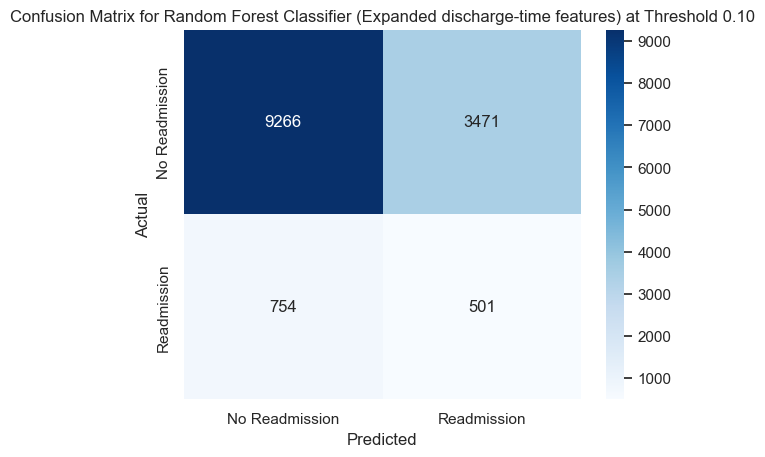

Test ROC-AUC: 0.593
Test average precision: 0.133


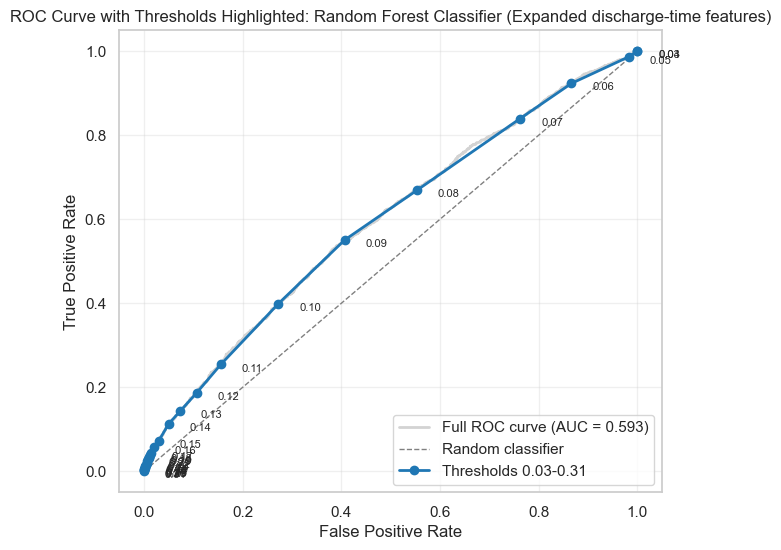

,threshold,fpr,tpr
0,0.03,1.000000,1.000000
1,0.04,1.000000,1.000000
2,0.05,0.983513,0.987251
3,0.06,0.866609,0.923506
4,0.07,0.762581,0.839841
5,0.08,0.553584,0.669323
6,0.09,0.406611,0.550598
7,0.10,0.272513,0.399203
8,0.11,0.155453,0.254183
9,0.12,0.106383,0.186454


Random forest predicted-probability summary by actual outcome


,count,mean,std,min,5%,10%,25%,50%,75%,90%,95%,max
y_true,,,,,,,,,,,,
0,12737.0,0.088577,0.028574,0.040661,0.053548,0.057115,0.071017,0.082622,0.101973,0.122146,0.140003,0.306399
1,1255.0,0.099869,0.038204,0.040604,0.056935,0.063519,0.076628,0.093716,0.111054,0.143271,0.165006,0.336177


,model,feature_set,f1,precision,recall,specificity,balanced_accuracy,roc_auc,average_precision
0,Paper-style baseline logistic regression,Baseline admission-time features,0.180860,0.107324,0.574502,0.529167,0.551834,0.586419,0.128292
1,Expanded discharge-time logistic regression,Expanded discharge-time features,0.189892,0.114525,0.555378,0.576902,0.566140,0.590409,0.129145
2,Polynomial logistic regression degree 2 at threshold 0.51,Expanded discharge-time polynomial features,0.188901,0.117998,0.473307,0.651409,0.562358,0.590237,0.129405
3,Gradient boosted trees at threshold 0.09,Expanded discharge-time features,0.189303,0.114029,0.556972,0.573604,0.565288,0.592283,0.131838
4,Random forest at threshold 0.10,Expanded discharge-time features,0.191697,0.126133,0.399203,0.727487,0.563345,0.593392,0.133454


In [30]:
from sklearn.ensemble import RandomForestClassifier

# Tune a compact random forest grid on the same expanded train/test split.
# GridSearchCV handles parallelism, so the estimator itself uses n_jobs=1.
random_forest_param_grid = {
    "model__n_estimators": [300],
    "model__max_depth": [8, 14, None],
    "model__min_samples_leaf": [25, 75],
    "model__max_features": ["sqrt", 0.5],
    "model__class_weight": [None, "balanced_subsample"],
}

random_forest_threshold_values = np.arange(0.03, 0.31, 0.01)

# The selected forest may output low probabilities, so inspect lower thresholds too.
random_forest_results = evaluate_model(
    RandomForestClassifier(
        random_state=42,
        n_jobs=1,
    ),
    X_train_expanded,
    y_train_expanded,
    X_test_expanded,
    y_test_expanded,
    model_name=f"Random Forest Classifier ({EXPANDED_FEATURE_SET})",
    param_grid=random_forest_param_grid,
    scoring="average_precision",
    cv=5,
    threshold="best_balanced_accuracy",
    threshold_values=random_forest_threshold_values,
    plot_roc_auc=True,
)

comparison_base = gradient_boosting_comparison if "gradient_boosting_comparison" in globals() else model_comparison

random_forest_scores = pd.DataFrame({
    "y_true": y_test_expanded,
    "score": random_forest_results["y_score"],
})

print("Random forest predicted-probability summary by actual outcome")
display(
    random_forest_scores.groupby("y_true")["score"]
    .describe(percentiles=[0.05, 0.10, 0.25, 0.50, 0.75, 0.90, 0.95])
)

random_forest_comparison = append_model_result(
    comparison_base,
    f"Random forest at threshold {random_forest_results['selected_threshold']:.2f}",
    random_forest_results,
    EXPANDED_FEATURE_SET,
)

display(random_forest_comparison)


## 9. Linear support vector machine comparison

A linear support vector machine is a reasonable comparison model for the one-hot encoded feature matrix. It learns a linear decision boundary like logistic regression, but optimizes a margin-based objective. A kernel SVM is not used here because it is much slower on this dataset size and would be harder to tune in the notebook.


Best parameters: {'model__C': 0.003, 'model__class_weight': None, 'model__max_iter': 10000}
Best cross-validation score: 0.1379545586733014
Selected threshold by validation balanced_accuracy: -0.80


,threshold,f1,precision,recall,specificity,balanced_accuracy
0,-1.000000e+00,0.164617,0.089691,1.000000,0.000000,0.500000
1,-9.500000e-01,0.164573,0.089680,0.998008,0.001865,0.499936
2,-9.000000e-01,0.169729,0.093168,0.952191,0.086850,0.519521
3,-8.500000e-01,0.182405,0.103640,0.759960,0.352404,0.556182
4,-8.000000e-01,0.202651,0.130838,0.449203,0.705986,0.577595
5,-7.500000e-01,0.192341,0.170788,0.220120,0.894701,0.557410
6,-7.000000e-01,0.133590,0.188065,0.103586,0.955937,0.529761
7,-6.500000e-01,0.085622,0.226496,0.052789,0.982237,0.517513
8,-6.000000e-01,0.059233,0.236111,0.033865,0.989205,0.511535
9,-5.500000e-01,0.056889,0.264463,0.031873,0.991266,0.511569


              precision    recall  f1-score   support

           0       0.93      0.71      0.80     12737
           1       0.12      0.43      0.19      1255

    accuracy                           0.68     13992
   macro avg       0.53      0.57      0.50     13992
weighted avg       0.85      0.68      0.75     13992



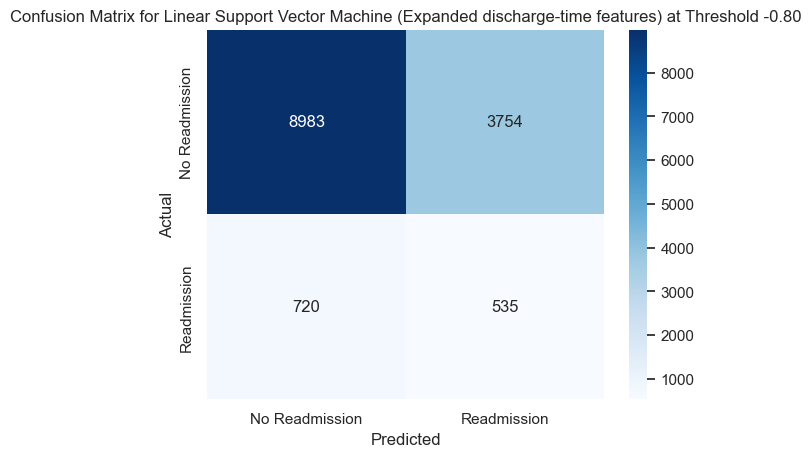

Test ROC-AUC: 0.589
Test average precision: 0.129


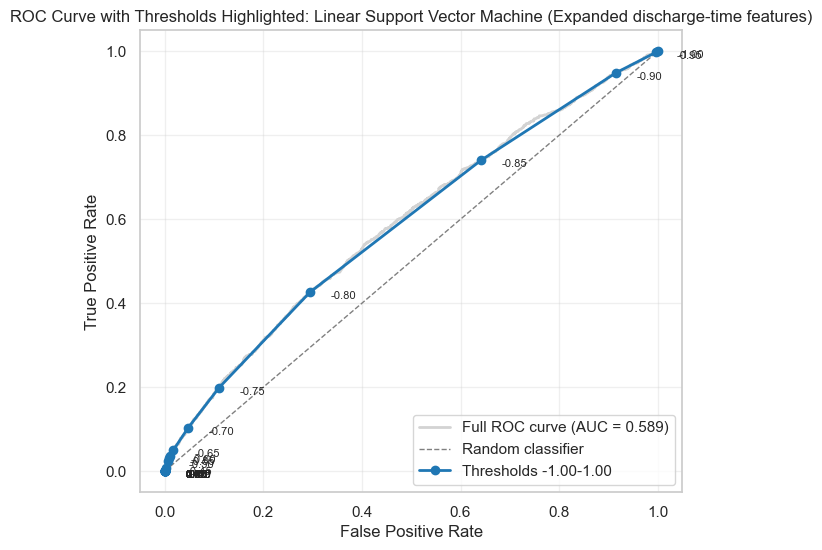

,threshold,fpr,tpr
0,-1.000000e+00,1.000000,1.000000
1,-9.500000e-01,0.996624,0.997610
2,-9.000000e-01,0.915679,0.949004
3,-8.500000e-01,0.641438,0.740239
4,-8.000000e-01,0.294732,0.426295
5,-7.500000e-01,0.109995,0.198406
6,-7.000000e-01,0.047813,0.103586
7,-6.500000e-01,0.017665,0.050199
8,-6.000000e-01,0.011306,0.037450
9,-5.500000e-01,0.009421,0.032669


,model,feature_set,f1,precision,recall,specificity,balanced_accuracy,roc_auc,average_precision
0,Paper-style baseline logistic regression,Baseline admission-time features,0.180860,0.107324,0.574502,0.529167,0.551834,0.586419,0.128292
1,Expanded discharge-time logistic regression,Expanded discharge-time features,0.189892,0.114525,0.555378,0.576902,0.566140,0.590409,0.129145
2,Polynomial logistic regression degree 2 at threshold 0.51,Expanded discharge-time polynomial features,0.188901,0.117998,0.473307,0.651409,0.562358,0.590237,0.129405
3,Gradient boosted trees at threshold 0.09,Expanded discharge-time features,0.189303,0.114029,0.556972,0.573604,0.565288,0.592283,0.131838
4,Random forest at threshold 0.10,Expanded discharge-time features,0.191697,0.126133,0.399203,0.727487,0.563345,0.593392,0.133454
5,Linear SVM at threshold -0.80,Expanded discharge-time features,0.193001,0.124738,0.426295,0.705268,0.565781,0.589238,0.129220


In [31]:
from sklearn.svm import LinearSVC

# LinearSVC exposes decision_function scores rather than probabilities.
# The evaluation helper can still use those continuous scores for ROC-AUC and thresholding.
linear_svm_param_grid = {
    "model__C": [0.001, 0.003, 0.01, 0.03, 0.1],
    "model__class_weight": [None, "balanced"],
    "model__max_iter": [10000],
}

linear_svm_threshold_values = np.arange(-1.0, 1.01, 0.05)

linear_svm_results = evaluate_model(
    LinearSVC(
        random_state=42,
        dual="auto",
    ),
    X_train_expanded,
    y_train_expanded,
    X_test_expanded,
    y_test_expanded,
    model_name=f"Linear Support Vector Machine ({EXPANDED_FEATURE_SET})",
    param_grid=linear_svm_param_grid,
    scoring="average_precision",
    cv=5,
    threshold="best_balanced_accuracy",
    threshold_values=linear_svm_threshold_values,
    plot_roc_auc=True,
)

comparison_base = random_forest_comparison if "random_forest_comparison" in globals() else model_comparison

linear_svm_comparison = append_model_result(
    comparison_base,
    f"Linear SVM at threshold {linear_svm_results['selected_threshold']:.2f}",
    linear_svm_results,
    EXPANDED_FEATURE_SET,
)

display(linear_svm_comparison)


## 9a. Approximate RBF-kernel SVM comparison

A full kernel SVM with `SVC(kernel="rbf")` is usually not practical for this dataset size because it requires storing and optimizing over a large kernel matrix. To still test the kernel idea, this section uses `Nystroem` to build an approximate RBF-kernel feature map, then fits a linear SVM on those transformed features. This keeps the experiment close to the kernel-trick idea while staying runnable in the notebook.


Best parameters: {'model__C': 0.03, 'model__class_weight': None, 'model__max_iter': 10000, 'nystroem__gamma': 0.03, 'nystroem__n_components': 300}
Best cross-validation score: 0.13652226365351808
Selected threshold by validation balanced_accuracy: -0.80


,threshold,f1,precision,recall,specificity,balanced_accuracy
0,-1.000000e+00,0.164617,0.089691,1.000000,0.000000,0.500000
1,-9.500000e-01,0.164752,0.089771,1.000000,0.000981,0.500491
2,-9.000000e-01,0.170473,0.093550,0.959163,0.084298,0.521731
3,-8.500000e-01,0.180532,0.102863,0.737052,0.366634,0.551843
4,-8.000000e-01,0.209277,0.134274,0.474104,0.698822,0.586463
5,-7.500000e-01,0.192260,0.165118,0.230080,0.885378,0.557729
6,-7.000000e-01,0.139232,0.200750,0.106574,0.958194,0.532384
7,-6.500000e-01,0.087676,0.258537,0.052789,0.985083,0.518936
8,-6.000000e-01,0.053571,0.258621,0.029880,0.991560,0.510720
9,-5.500000e-01,0.031985,0.288136,0.016932,0.995878,0.506405


              precision    recall  f1-score   support

           0       0.93      0.70      0.80     12737
           1       0.12      0.43      0.19      1255

    accuracy                           0.67     13992
   macro avg       0.52      0.57      0.49     13992
weighted avg       0.85      0.67      0.74     13992



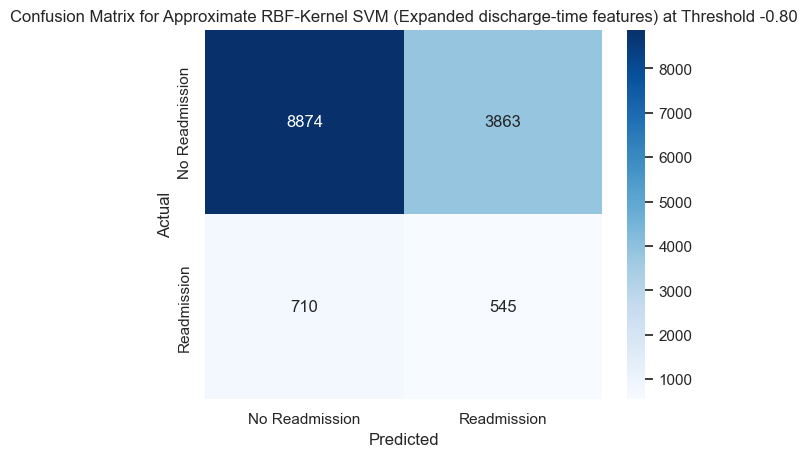

Test ROC-AUC: 0.591
Test average precision: 0.129


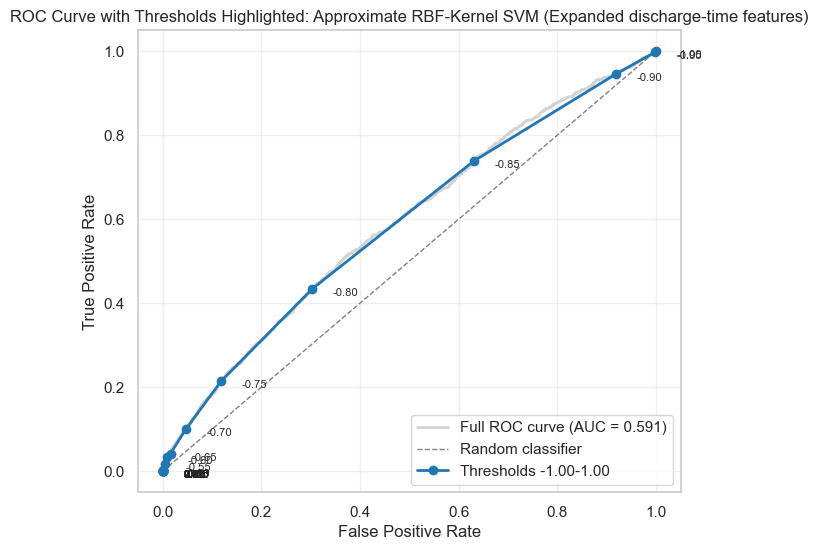

,threshold,fpr,tpr
0,-1.000000e+00,1.000000,1.000000
1,-9.500000e-01,0.999058,0.998406
2,-9.000000e-01,0.919212,0.945817
3,-8.500000e-01,0.630996,0.738645
4,-8.000000e-01,0.303290,0.434263
5,-7.500000e-01,0.118474,0.214343
6,-7.000000e-01,0.047107,0.100398
7,-6.500000e-01,0.015938,0.042231
8,-6.000000e-01,0.008715,0.033466
9,-5.500000e-01,0.004868,0.018327


,model,feature_set,f1,precision,recall,specificity,balanced_accuracy,roc_auc,average_precision
0,Paper-style baseline logistic regression,Baseline admission-time features,0.180860,0.107324,0.574502,0.529167,0.551834,0.586419,0.128292
1,Expanded discharge-time logistic regression,Expanded discharge-time features,0.189892,0.114525,0.555378,0.576902,0.566140,0.590409,0.129145
2,Polynomial logistic regression degree 2 at threshold 0.51,Expanded discharge-time polynomial features,0.188901,0.117998,0.473307,0.651409,0.562358,0.590237,0.129405
3,Gradient boosted trees at threshold 0.09,Expanded discharge-time features,0.189303,0.114029,0.556972,0.573604,0.565288,0.592283,0.131838
4,Random forest at threshold 0.10,Expanded discharge-time features,0.191697,0.126133,0.399203,0.727487,0.563345,0.593392,0.133454
5,Linear SVM at threshold -0.80,Expanded discharge-time features,0.193001,0.124738,0.426295,0.705268,0.565781,0.589238,0.129220
6,Approximate RBF-kernel SVM at threshold -0.80,Expanded discharge-time features,0.192477,0.123639,0.434263,0.696710,0.565487,0.591254,0.129335


In [32]:
from sklearn.kernel_approximation import Nystroem
from sklearn.pipeline import Pipeline

# Approximate an RBF-kernel SVM with a Nystroem feature map followed by LinearSVC.
# This is much more scalable than fitting full SVC(kernel="rbf") on the full dataset.
rbf_svm_pipeline = Pipeline([
    ("nystroem", Nystroem(kernel="rbf", random_state=42)),
    ("model", LinearSVC(random_state=42, dual="auto")),
])

rbf_svm_param_grid = {
    "nystroem__gamma": [0.01, 0.03, 0.10],
    "nystroem__n_components": [100, 300],
    "model__C": [0.01, 0.03, 0.10],
    "model__class_weight": [None, "balanced"],
    "model__max_iter": [10000],
}

rbf_svm_threshold_values = np.arange(-1.0, 1.01, 0.05)

rbf_svm_results = evaluate_model(
    rbf_svm_pipeline,
    X_train_expanded,
    y_train_expanded,
    X_test_expanded,
    y_test_expanded,
    model_name=f"Approximate RBF-Kernel SVM ({EXPANDED_FEATURE_SET})",
    param_grid=rbf_svm_param_grid,
    scoring="average_precision",
    # Keep this approximate-kernel search at 3 folds because the Nystroem
    # transform is the most expensive SVM experiment in the notebook.
    cv=3,
    n_jobs=1,
    threshold="best_balanced_accuracy",
    threshold_values=rbf_svm_threshold_values,
    plot_roc_auc=True,
)

comparison_base = linear_svm_comparison if "linear_svm_comparison" in globals() else model_comparison

rbf_svm_comparison = append_model_result(
    comparison_base,
    f"Approximate RBF-kernel SVM at threshold {rbf_svm_results['selected_threshold']:.2f}",
    rbf_svm_results,
    EXPANDED_FEATURE_SET,
)

display(rbf_svm_comparison)


## 10. Neural network comparison

As a final exploratory benchmark, we fit a small multilayer perceptron neural network. This model can learn nonlinear combinations of the encoded features, but it is less interpretable and more sensitive to tuning than logistic regression. Given the weak signal seen so far, this section is treated as an exploratory comparison rather than a primary modeling strategy.


Best parameters: {'model__activation': 'relu', 'model__alpha': 0.01, 'model__batch_size': 512, 'model__hidden_layer_sizes': (64, 32), 'model__learning_rate': 'constant', 'model__learning_rate_init': 0.001}
Best cross-validation score: 0.1159681953966193
Selected threshold by validation balanced_accuracy: 0.11


,threshold,f1,precision,recall,specificity,balanced_accuracy
0,0.03,0.164739,0.089763,1.000000,0.000883,0.500442
1,0.04,0.164945,0.089934,0.994024,0.008930,0.501477
2,0.05,0.167713,0.091782,0.971116,0.053189,0.512152
3,0.06,0.172805,0.095302,0.925299,0.134544,0.529921
4,0.07,0.174798,0.097567,0.838645,0.235721,0.537183
5,0.08,0.182137,0.104170,0.724104,0.386457,0.555280
6,0.09,0.191115,0.112377,0.638446,0.503140,0.570793
7,0.10,0.199853,0.122624,0.539841,0.619431,0.579636
8,0.11,0.207441,0.134072,0.458167,0.708440,0.583303
9,0.12,0.206044,0.142261,0.373506,0.778116,0.575811


              precision    recall  f1-score   support

           0       0.92      0.71      0.80     12737
           1       0.12      0.41      0.19      1255

    accuracy                           0.68     13992
   macro avg       0.52      0.56      0.50     13992
weighted avg       0.85      0.68      0.75     13992



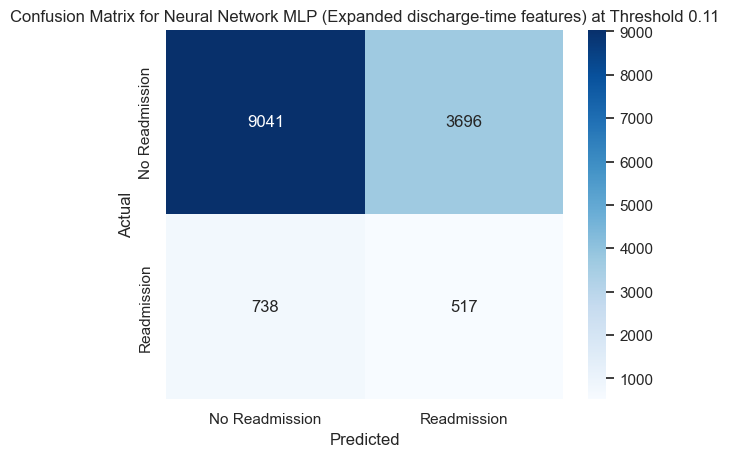

Test ROC-AUC: 0.587
Test average precision: 0.128


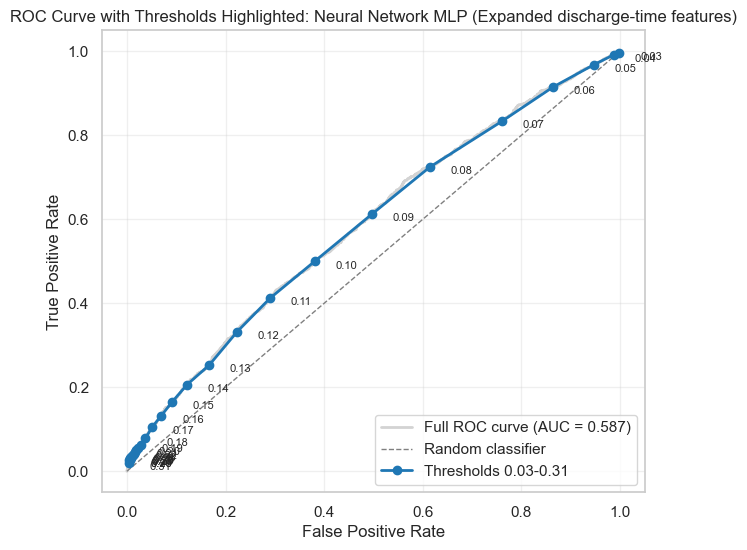

,threshold,fpr,tpr
0,0.03,0.998273,0.996813
1,0.04,0.987909,0.992032
2,0.05,0.947005,0.968127
3,0.06,0.863940,0.914741
4,0.07,0.760619,0.833466
5,0.08,0.614273,0.724303
6,0.09,0.496585,0.611952
7,0.10,0.380466,0.499602
8,0.11,0.290178,0.411952
9,0.12,0.223522,0.332271


,model,feature_set,f1,precision,recall,specificity,balanced_accuracy,roc_auc,average_precision
0,Paper-style baseline logistic regression,Baseline admission-time features,0.180860,0.107324,0.574502,0.529167,0.551834,0.586419,0.128292
1,Expanded discharge-time logistic regression,Expanded discharge-time features,0.189892,0.114525,0.555378,0.576902,0.566140,0.590409,0.129145
2,Polynomial logistic regression degree 2 at threshold 0.51,Expanded discharge-time polynomial features,0.188901,0.117998,0.473307,0.651409,0.562358,0.590237,0.129405
3,Gradient boosted trees at threshold 0.09,Expanded discharge-time features,0.189303,0.114029,0.556972,0.573604,0.565288,0.592283,0.131838
4,Random forest at threshold 0.10,Expanded discharge-time features,0.191697,0.126133,0.399203,0.727487,0.563345,0.593392,0.133454
5,Linear SVM at threshold -0.80,Expanded discharge-time features,0.193001,0.124738,0.426295,0.705268,0.565781,0.589238,0.129220
6,Approximate RBF-kernel SVM at threshold -0.80,Expanded discharge-time features,0.192477,0.123639,0.434263,0.696710,0.565487,0.591254,0.129335
7,Neural network at threshold 0.11,Expanded discharge-time features,0.189100,0.122715,0.411952,0.709822,0.560887,0.586632,0.128478


In [33]:
from sklearn.pipeline import Pipeline
from sklearn.neural_network import MLPClassifier
from sklearn.preprocessing import MaxAbsScaler

# MaxAbsScaler preserves sparse one-hot scale without inflating rare categories.
mlp_pipeline = Pipeline([
    ("scaler", MaxAbsScaler()),
    ("model", MLPClassifier(
        random_state=42,
        early_stopping=True,
        validation_fraction=0.1,
        max_iter=1000,
        n_iter_no_change=15,
    )),
])

# Compact exploratory grid to limit overfitting and runtime on a weak-signal tabular task.
mlp_param_grid = {
    "model__activation": ["relu"],
    "model__hidden_layer_sizes": [
        (32,),
        (64,),
        (64, 32),
    ],
    "model__alpha": [0.001, 0.01],
    "model__learning_rate_init": [0.0005, 0.001],
    "model__learning_rate": ["constant", "adaptive"],
    "model__batch_size": [512],
}

mlp_threshold_values = np.arange(0.03, 0.31, 0.01)

mlp_results = evaluate_model(
    mlp_pipeline,
    X_train_expanded,
    y_train_expanded,
    X_test_expanded,
    y_test_expanded,
    model_name=f"Neural Network MLP ({EXPANDED_FEATURE_SET})",
    param_grid=mlp_param_grid,
    scoring="average_precision",
    # Keep this exploratory neural-network search at 3 folds to limit runtime.
    cv=3,
    threshold="best_balanced_accuracy",
    threshold_values=mlp_threshold_values,
    plot_roc_auc=True,
)

comparison_base = rbf_svm_comparison if "rbf_svm_comparison" in globals() else linear_svm_comparison if "linear_svm_comparison" in globals() else model_comparison

mlp_comparison = append_model_result(
    comparison_base,
    f"Neural network at threshold {mlp_results['selected_threshold']:.2f}",
    mlp_results,
    EXPANDED_FEATURE_SET,
)

display(mlp_comparison)


## 10a. Neural network with degree-2 polynomial features

This section repeats the neural network experiment using the degree-2 polynomial feature matrix from section 6a. The polynomial expansion adds pairwise interactions between the encoded baseline and lab-result features, while the MLP can learn nonlinear combinations of those interaction terms. Because the polynomial matrix is larger than the original encoded feature matrix, this grid is intentionally smaller than the previous neural-network search. The grid search is run serially to avoid memory pressure from copying the wider polynomial matrix across parallel workers.


Best parameters: {'model__activation': 'relu', 'model__alpha': 0.01, 'model__batch_size': 512, 'model__hidden_layer_sizes': (64,), 'model__learning_rate': 'constant', 'model__learning_rate_init': 0.001}
Best cross-validation score: 0.1219560713064808
Selected threshold by validation balanced_accuracy: 0.11


,threshold,f1,precision,recall,specificity,balanced_accuracy
0,0.03,0.164617,0.089691,1.000000,0.000000,0.500000
1,0.04,0.164938,0.089898,0.998008,0.004514,0.501261
2,0.05,0.167588,0.091619,0.981076,0.041609,0.511343
3,0.06,0.170371,0.093722,0.935259,0.108930,0.522095
4,0.07,0.173705,0.096503,0.868526,0.198822,0.533674
5,0.08,0.181714,0.102717,0.786853,0.322767,0.554810
6,0.09,0.185842,0.107798,0.673307,0.450932,0.562120
7,0.10,0.192249,0.116011,0.560757,0.578999,0.569878
8,0.11,0.197741,0.125779,0.462151,0.683513,0.572832
9,0.12,0.201835,0.136962,0.383466,0.761923,0.572695


              precision    recall  f1-score   support

           0       0.92      0.68      0.78     12737
           1       0.12      0.44      0.19      1255

    accuracy                           0.66     13992
   macro avg       0.52      0.56      0.49     13992
weighted avg       0.85      0.66      0.73     13992



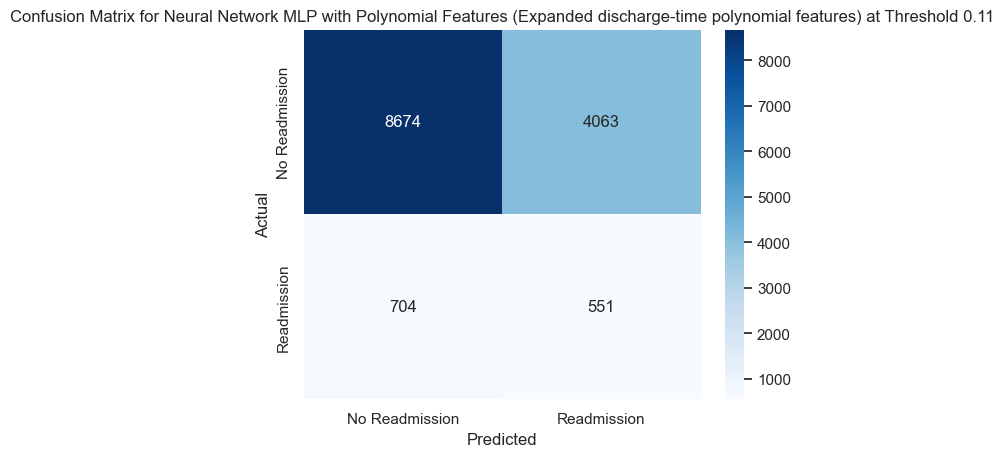

Test ROC-AUC: 0.578
Test average precision: 0.117


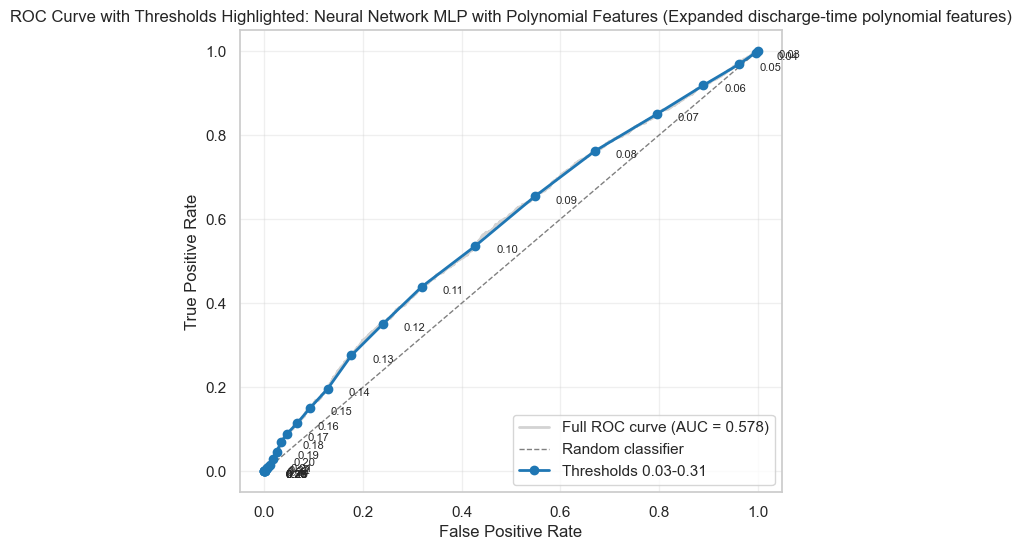

,threshold,fpr,tpr
0,0.03,1.000000,1.000000
1,0.04,0.996467,0.996813
2,0.05,0.962315,0.968924
3,0.06,0.889927,0.918725
4,0.07,0.795635,0.850199
5,0.08,0.670409,0.762550
6,0.09,0.548245,0.654183
7,0.10,0.427573,0.536255
8,0.11,0.318992,0.439044
9,0.12,0.240402,0.350598


,model,feature_set,f1,precision,recall,specificity,balanced_accuracy,roc_auc,average_precision
0,Paper-style baseline logistic regression,Baseline admission-time features,0.180860,0.107324,0.574502,0.529167,0.551834,0.586419,0.128292
1,Expanded discharge-time logistic regression,Expanded discharge-time features,0.189892,0.114525,0.555378,0.576902,0.566140,0.590409,0.129145
2,Polynomial logistic regression degree 2 at threshold 0.51,Expanded discharge-time polynomial features,0.188901,0.117998,0.473307,0.651409,0.562358,0.590237,0.129405
3,Gradient boosted trees at threshold 0.09,Expanded discharge-time features,0.189303,0.114029,0.556972,0.573604,0.565288,0.592283,0.131838
4,Random forest at threshold 0.10,Expanded discharge-time features,0.191697,0.126133,0.399203,0.727487,0.563345,0.593392,0.133454
5,Linear SVM at threshold -0.80,Expanded discharge-time features,0.193001,0.124738,0.426295,0.705268,0.565781,0.589238,0.129220
6,Approximate RBF-kernel SVM at threshold -0.80,Expanded discharge-time features,0.192477,0.123639,0.434263,0.696710,0.565487,0.591254,0.129335
7,Neural network at threshold 0.11,Expanded discharge-time features,0.189100,0.122715,0.411952,0.709822,0.560887,0.586632,0.128478
8,Neural network with polynomial features at threshold 0.11,Expanded discharge-time polynomial features,0.187766,0.119419,0.439044,0.681008,0.560026,0.577724,0.117111


In [34]:
# Reuse the degree-2 polynomial feature matrices created in section 6a.
# If section 6a has not been run in the current notebook session, run it before this cell.

mlp_polynomial_pipeline = Pipeline([
    ("scaler", MaxAbsScaler()),
    ("model", MLPClassifier(
        random_state=42,
        early_stopping=True,
        validation_fraction=0.1,
        max_iter=1000,
        n_iter_no_change=12,
    )),
])

# Smaller grid than section 10 because the polynomial feature matrix is much wider.
mlp_polynomial_param_grid = {
    "model__activation": ["relu"],
    "model__hidden_layer_sizes": [(32,), (64,), (64, 32)],
    "model__alpha": [0.001, 0.01],
    "model__learning_rate_init": [0.0005, 0.001],
    "model__learning_rate": ["constant"],
    "model__batch_size": [512],
}

mlp_polynomial_threshold_values = np.arange(0.03, 0.31, 0.01)

mlp_polynomial_results = evaluate_model(
    mlp_polynomial_pipeline,
    X_train_polynomial_reduced,
    y_train_expanded,
    X_test_polynomial_reduced,
    y_test_expanded,
    model_name=f"Neural Network MLP with Polynomial Features ({POLYNOMIAL_FEATURE_SET})",
    param_grid=mlp_polynomial_param_grid,
    scoring="average_precision",
    # Keep this wider polynomial-feature neural-network search at 3 folds
    # because the grid is run serially to avoid memory pressure.
    cv=3,
    n_jobs=1,
    threshold="best_balanced_accuracy",
    threshold_values=mlp_polynomial_threshold_values,
    plot_roc_auc=True,
)

comparison_base = mlp_comparison if "mlp_comparison" in globals() else model_comparison

mlp_polynomial_comparison = append_model_result(
    comparison_base,
    f"Neural network with polynomial features at threshold {mlp_polynomial_results['selected_threshold']:.2f}",
    mlp_polynomial_results,
    POLYNOMIAL_FEATURE_SET,
)

display(mlp_polynomial_comparison)


## 11. Final model comparison

The table below gathers the test-set metrics from every fitted model above. Average precision and ROC-AUC compare ranking quality under class imbalance, while the threshold-dependent columns use each model's selected operating threshold. The expanded models use discharge-time information, including HbA1c/glucose results, length of stay, and medication-change status.


In [35]:
final_model_result_specs = [
    ("Paper-style baseline logistic regression", "Baseline admission-time features", paper_baseline_tuned_results),
    ("Expanded discharge-time logistic regression", "Expanded discharge-time features", expanded_tuned_results),
    ("Polynomial logistic regression degree 2", "Expanded discharge-time polynomial features", polynomial_logistic_results),
    ("Gradient boosted trees", "Expanded discharge-time features", gradient_boosting_results),
    ("Random forest", "Expanded discharge-time features", random_forest_results),
    ("Linear SVM", "Expanded discharge-time features", linear_svm_results),
    ("Approximate RBF-kernel SVM", "Expanded discharge-time features", rbf_svm_results),
    ("Neural network MLP", "Expanded discharge-time features", mlp_results),
    ("Neural network MLP with polynomial features", "Expanded discharge-time polynomial features", mlp_polynomial_results),
]


def final_prediction_counts(y_true, y_pred):
    y_true_array = np.asarray(y_true).ravel()
    y_pred_array = np.asarray(y_pred).ravel()
    return {
        "true_positives": int(((y_true_array == 1) & (y_pred_array == 1)).sum()),
        "false_positives": int(((y_true_array == 0) & (y_pred_array == 1)).sum()),
    }


final_model_comparison = pd.DataFrame([
    {
        "model": model_name,
        "feature_set": feature_set,
        "selected_threshold": result["selected_threshold"],
        "threshold_selection_source": result.get("threshold_selection_source"),
        **final_prediction_counts(y_test_expanded, result["y_pred"]),
        **result["metrics"],
    }
    for model_name, feature_set, result in final_model_result_specs
])

final_metric_columns = [
    "model",
    "feature_set",
    "selected_threshold",
    "threshold_selection_source",
    "true_positives",
    "false_positives",
    "f1",
    "precision",
    "recall",
    "specificity",
    "balanced_accuracy",
    "roc_auc",
    "average_precision",
]

final_model_comparison = (
    final_model_comparison.loc[
        :, [column for column in final_metric_columns if column in final_model_comparison.columns]
    ]
    .sort_values("average_precision", ascending=False)
    .reset_index(drop=True)
)

display(final_model_comparison)


,model,feature_set,selected_threshold,threshold_selection_source,true_positives,false_positives,f1,precision,recall,specificity,balanced_accuracy,roc_auc,average_precision
0,Random forest,Expanded discharge-time features,0.10,validation,501,3471,0.191697,0.126133,0.399203,0.727487,0.563345,0.593392,0.133454
1,Gradient boosted trees,Expanded discharge-time features,0.09,validation,699,5431,0.189303,0.114029,0.556972,0.573604,0.565288,0.592283,0.131838
2,Polynomial logistic regression degree 2,Expanded discharge-time polynomial features,0.51,validation,594,4440,0.188901,0.117998,0.473307,0.651409,0.562358,0.590237,0.129405
3,Approximate RBF-kernel SVM,Expanded discharge-time features,-0.80,validation,545,3863,0.192477,0.123639,0.434263,0.696710,0.565487,0.591254,0.129335
4,Linear SVM,Expanded discharge-time features,-0.80,validation,535,3754,0.193001,0.124738,0.426295,0.705268,0.565781,0.589238,0.129220
5,Expanded discharge-time logistic regression,Expanded discharge-time features,0.49,validation,697,5389,0.189892,0.114525,0.555378,0.576902,0.566140,0.590409,0.129145
6,Neural network MLP,Expanded discharge-time features,0.11,validation,517,3696,0.189100,0.122715,0.411952,0.709822,0.560887,0.586632,0.128478
7,Paper-style baseline logistic regression,Baseline admission-time features,0.49,validation,721,5997,0.180860,0.107324,0.574502,0.529167,0.551834,0.586419,0.128292
8,Neural network MLP with polynomial features,Expanded discharge-time polynomial features,0.11,validation,551,4063,0.187766,0.119419,0.439044,0.681008,0.560026,0.577724,0.117111


## 12. SHAP explanations where model structure is interpretable

SHAP is added for models where the explanation stays tied to the feature matrix used by the model. This includes the logistic-regression models, tree models, and the linear SVM. The approximate RBF-kernel SVM is skipped because its classifier operates on Nystroem-transformed components rather than the original encoded clinical features. The neural-network models are skipped because model-agnostic SHAP would be much slower and less stable in this notebook.

Each plot is limited to the 10 most important features to keep the interpretation focused.

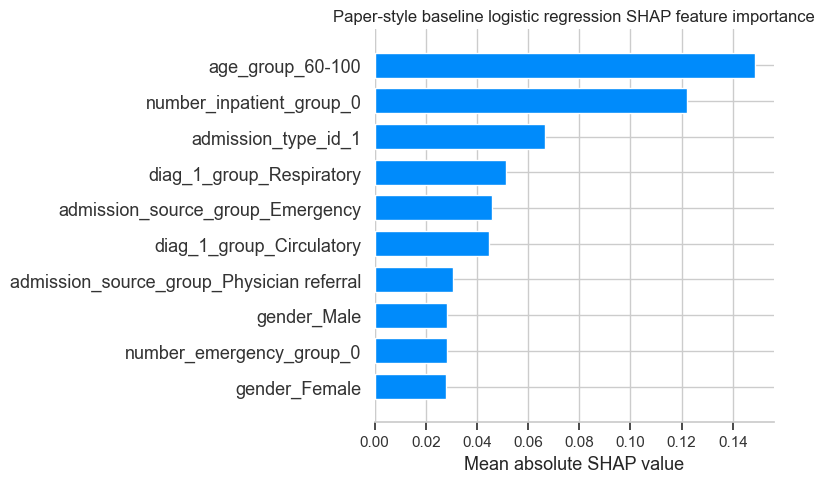

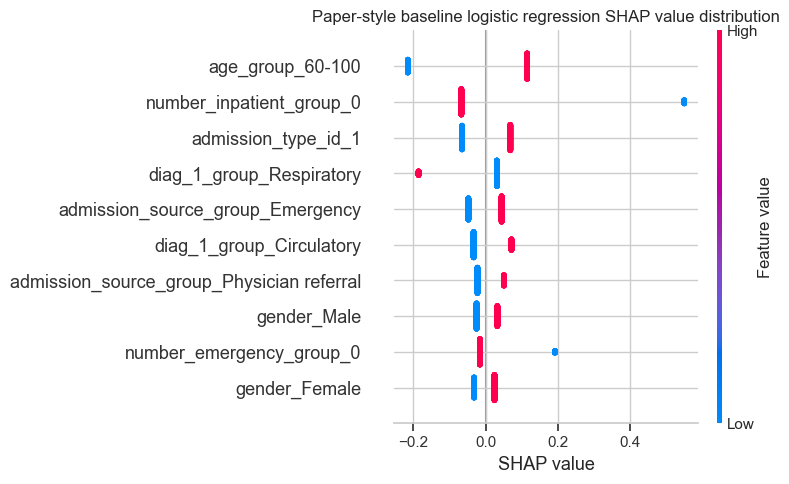

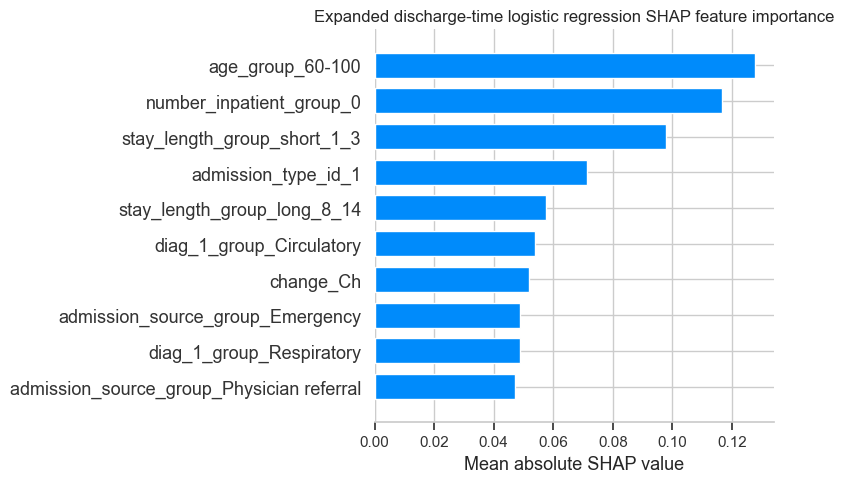

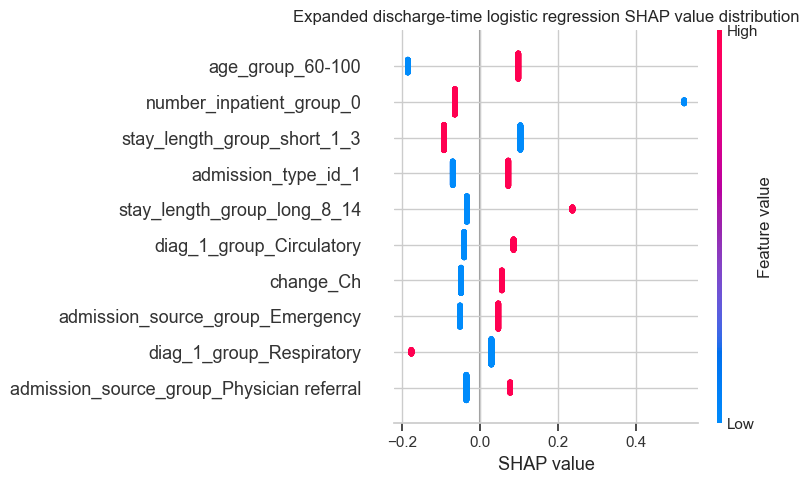

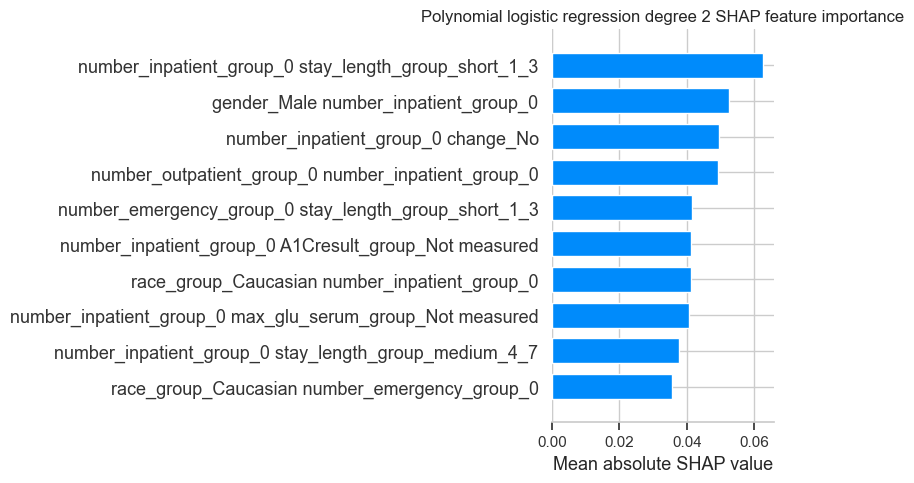

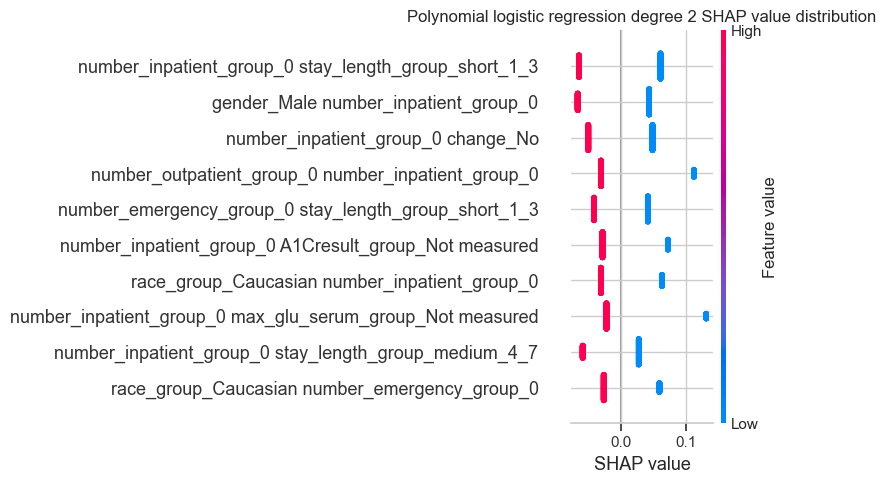

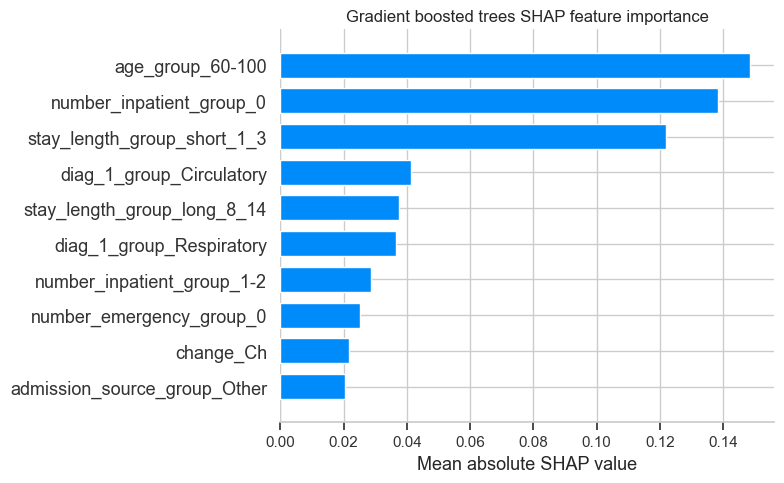

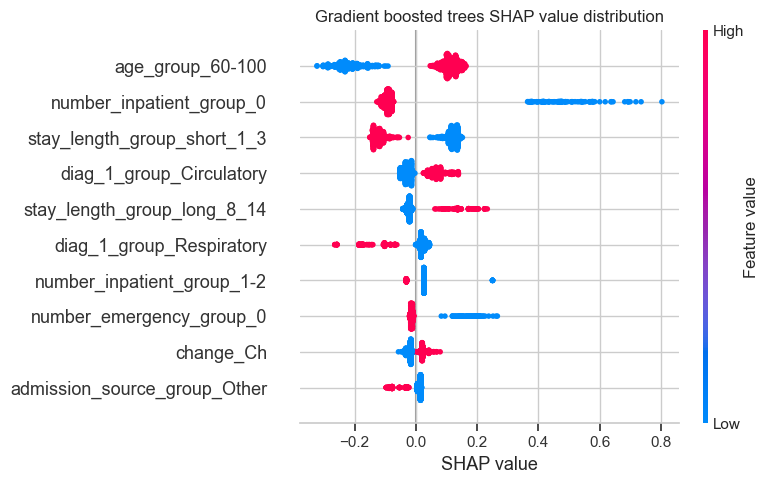

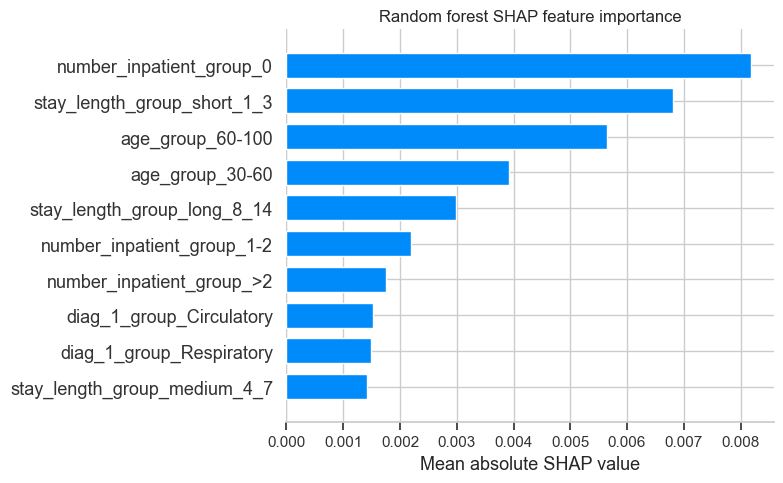

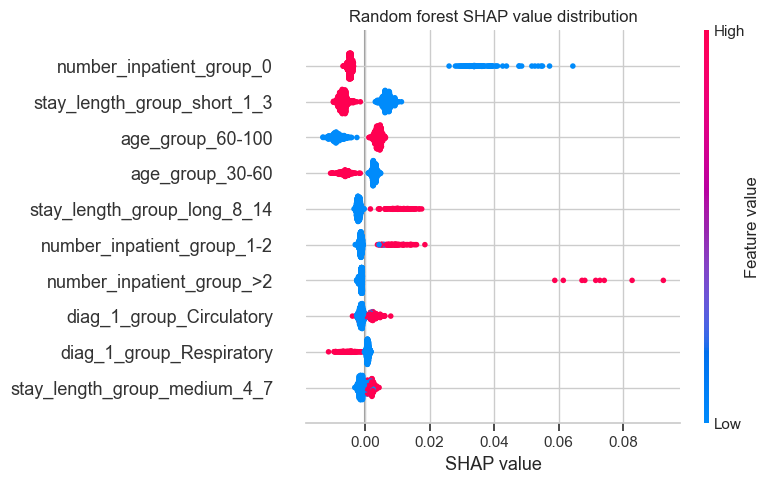

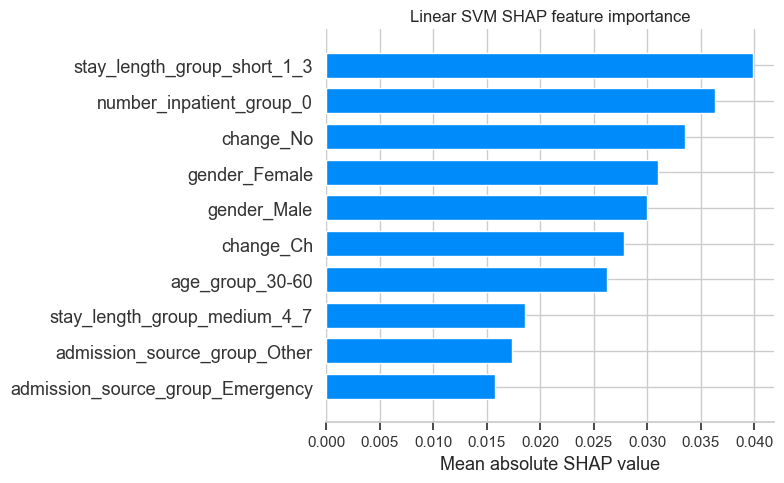

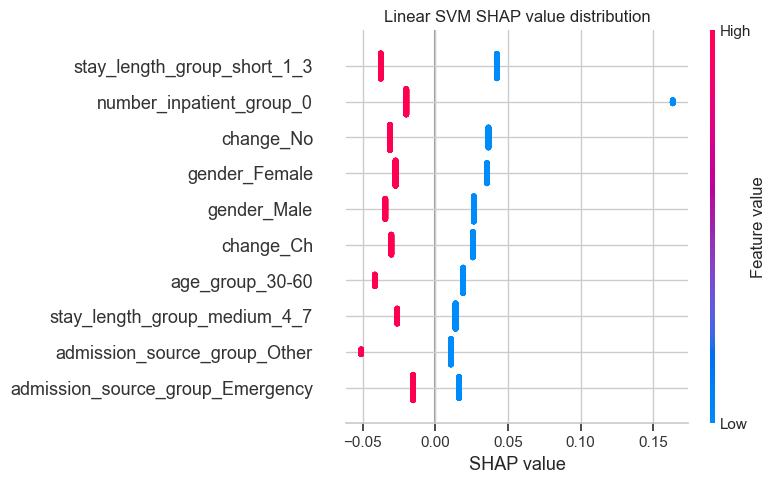

,model,feature_set,explainer,bar_plot,beeswarm_plot
0,Paper-style baseline logistic regression,Baseline admission-time features,linear,images/shap_paper_baseline_logistic_top10_bar.png,images/shap_paper_baseline_logistic_top10_beeswarm.png
1,Expanded discharge-time logistic regression,Expanded discharge-time features,linear,images/shap_expanded_logistic_top10_bar.png,images/shap_expanded_logistic_top10_beeswarm.png
2,Polynomial logistic regression degree 2,Expanded discharge-time polynomial features,linear,images/shap_polynomial_logistic_top10_bar.png,images/shap_polynomial_logistic_top10_beeswarm.png
3,Gradient boosted trees,Expanded discharge-time features,tree,images/shap_gradient_boosted_trees_top10_bar.png,images/shap_gradient_boosted_trees_top10_beeswarm.png
4,Random forest,Expanded discharge-time features,tree,images/shap_random_forest_top10_bar.png,images/shap_random_forest_top10_beeswarm.png
5,Linear SVM,Expanded discharge-time features,linear,images/shap_linear_svm_top10_bar.png,images/shap_linear_svm_top10_beeswarm.png


SHAP skipped for: Approximate RBF-kernel SVM, Neural network MLP, Neural network MLP with polynomial features


In [36]:
from tqdm import TqdmWarning

warnings.filterwarnings(
    "ignore",
    message="IProgress not found.*",
    category=TqdmWarning,
)

import shap  # noqa: E402

SHAP_MAX_DISPLAY = 10
SHAP_SAMPLE_SIZE = 1000
SHAP_BACKGROUND_SIZE = 1000
SHAP_RANDOM_STATE = 42

skipped_shap_models = [
    "Approximate RBF-kernel SVM",
    "Neural network MLP",
    "Neural network MLP with polynomial features",
]


def fitted_pipeline(result):
    estimator = result["estimator"]
    return estimator.best_estimator_ if hasattr(estimator, "best_estimator_") else estimator


def model_step(fitted_model):
    return fitted_model.named_steps["model"] if hasattr(fitted_model, "named_steps") else fitted_model


def sampled_frame(frame, sample_size, random_state=SHAP_RANDOM_STATE):
    return frame.sample(n=min(sample_size, len(frame)), random_state=random_state)


def positive_class_shap_values(shap_values):
    if isinstance(shap_values, list):
        return shap_values[1]

    shap_values_array = np.asarray(shap_values)
    if shap_values_array.ndim == 3:
        return shap_values_array[:, :, 1]
    return shap_values_array


def save_shap_plots(shap_values, feature_sample, model_label, file_stub):
    shap_output_dir = Path("images")
    shap_output_dir.mkdir(exist_ok=True)
    bar_path = shap_output_dir / f"shap_{file_stub}_top10_bar.png"
    beeswarm_path = shap_output_dir / f"shap_{file_stub}_top10_beeswarm.png"

    shap.summary_plot(
        shap_values,
        feature_sample,
        plot_type="bar",
        max_display=SHAP_MAX_DISPLAY,
        show=False,
    )
    plt.title(f"{model_label} SHAP feature importance")
    plt.xlabel("Mean absolute SHAP value")
    plt.gcf().set_size_inches(8, 5)
    plt.tight_layout()
    plt.savefig(bar_path, dpi=200, bbox_inches="tight")
    plt.show()

    shap.summary_plot(
        shap_values,
        feature_sample,
        max_display=SHAP_MAX_DISPLAY,
        show=False,
    )
    plt.title(f"{model_label} SHAP value distribution")
    plt.xlabel("SHAP value")
    plt.gcf().set_size_inches(8, 5)
    plt.tight_layout()
    plt.savefig(beeswarm_path, dpi=200, bbox_inches="tight")
    plt.show()

    return bar_path, beeswarm_path


def linear_model_shap(result, X_train, X_test, model_label, file_stub):
    fitted_model = fitted_pipeline(result)
    model = model_step(fitted_model)
    background = sampled_frame(X_train, SHAP_BACKGROUND_SIZE)
    feature_sample = sampled_frame(X_test, SHAP_SAMPLE_SIZE)
    masker = shap.maskers.Independent(background, max_samples=len(background))
    explainer = shap.LinearExplainer(model, masker)
    shap_values = positive_class_shap_values(explainer.shap_values(feature_sample))
    return save_shap_plots(shap_values, feature_sample, model_label, file_stub)


def tree_model_shap(result, X_test, model_label, file_stub):
    fitted_model = fitted_pipeline(result)
    model = model_step(fitted_model)
    feature_sample = sampled_frame(X_test, SHAP_SAMPLE_SIZE)
    explainer = shap.TreeExplainer(model)
    shap_values = positive_class_shap_values(explainer.shap_values(feature_sample))
    return save_shap_plots(shap_values, feature_sample, model_label, file_stub)


shap_plot_specs = [
    {
        "model": "Paper-style baseline logistic regression",
        "feature_set": BASELINE_FEATURE_SET,
        "explainer": "linear",
        "result": paper_baseline_tuned_results,
        "X_train": X_train_paper_baseline,
        "X_test": X_test_paper_baseline,
        "file_stub": "paper_baseline_logistic",
    },
    {
        "model": "Expanded discharge-time logistic regression",
        "feature_set": EXPANDED_FEATURE_SET,
        "explainer": "linear",
        "result": expanded_tuned_results,
        "X_train": X_train_expanded,
        "X_test": X_test_expanded,
        "file_stub": "expanded_logistic",
    },
    {
        "model": "Polynomial logistic regression degree 2",
        "feature_set": POLYNOMIAL_FEATURE_SET,
        "explainer": "linear",
        "result": polynomial_logistic_results,
        "X_train": X_train_polynomial_reduced,
        "X_test": X_test_polynomial_reduced,
        "file_stub": "polynomial_logistic",
    },
    {
        "model": "Gradient boosted trees",
        "feature_set": EXPANDED_FEATURE_SET,
        "explainer": "tree",
        "result": gradient_boosting_results,
        "X_test": X_test_expanded,
        "file_stub": "gradient_boosted_trees",
    },
    {
        "model": "Random forest",
        "feature_set": EXPANDED_FEATURE_SET,
        "explainer": "tree",
        "result": random_forest_results,
        "X_test": X_test_expanded,
        "file_stub": "random_forest",
    },
    {
        "model": "Linear SVM",
        "feature_set": EXPANDED_FEATURE_SET,
        "explainer": "linear",
        "result": linear_svm_results,
        "X_train": X_train_expanded,
        "X_test": X_test_expanded,
        "file_stub": "linear_svm",
    },
]

shap_plot_outputs = []
for spec in shap_plot_specs:
    if spec["explainer"] == "linear":
        bar_path, beeswarm_path = linear_model_shap(
            spec["result"],
            spec["X_train"],
            spec["X_test"],
            spec["model"],
            spec["file_stub"],
        )
    else:
        bar_path, beeswarm_path = tree_model_shap(
            spec["result"],
            spec["X_test"],
            spec["model"],
            spec["file_stub"],
        )

    shap_plot_outputs.append({
        "model": spec["model"],
        "feature_set": spec["feature_set"],
        "explainer": spec["explainer"],
        "bar_plot": str(bar_path),
        "beeswarm_plot": str(beeswarm_path),
    })

shap_plot_summary = pd.DataFrame(shap_plot_outputs)
display(shap_plot_summary)

print("SHAP skipped for:", ", ".join(skipped_shap_models))
